<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/reservoir/reservoir_well_topside_market_system_curves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reservoir-to-market system curves with a capacity-designed topside

This follow-up to the well nodal-analysis notebook connects one synthetic gas-condensate
reservoir and producer to a subsea flowline, a three-pressure topside separation train,
flash-gas recompression, two-stage export compression, and a 160 bara market boundary.

The notebook:

- calculates reservoir inflow performance (IPR);
- calculates tubing and gathering-system lift requirements;
- sizes HP, MP, and LP separators plus four compressor scrubbers;
- generates all speed, head, efficiency, surge, and stonewall compressor curves;
- evaluates vessel, compressor-map, recycle, speed, and driver utilization;
- optimizes the HP-separator pressure at every rate under all capacity constraints;
- finds the capacity-constrained reservoir-to-market operating point; and
- compares reservoir-pressure-aware lift curves and ranked debottlenecking options; and
- exports a standard ECLIPSE `VFPPROD` table whose THP axis remains the true wellhead
  pressure and whose rate axis is limited by the calculated topside capacity.

The case is synthetic and intended for teaching and screening. Vendor maps, pressure
surveys, fluid characterization, qualified multiphase correlations, design standards,
control logic, availability, and uncertainty are required for a real field decision.

## 1. Engineering basis and source

The system decomposition follows
[Field Development and Operations with NeqSim](https://equinor.github.io/neqsimhome/doc/field_development_and_operations/book_standalone.html):

reservoir $\rightarrow$ well $\rightarrow$ gathering $\rightarrow$ process
$\rightarrow$ export market.

The previous notebook explained the well-only IPR/VLP crossing. Here, the downstream
pressure requirement and capacity envelope are brought back to the wellhead. Absolute
pressure is used throughout. Gas rate is reported in MSm³/day, while actual compressor
suction flow is reported in m³/h.

A critical simulator convention is preserved: ECLIPSE `VFPPROD` describes tubing lift
from true tubing-head pressure (THP) to bottom-hole pressure (BHP). A market pressure is
**not** a THP. The full reservoir-to-market curve is therefore exported separately as a
capacity table, while `VFPPROD` retains standard well semantics.

## 2. Pressure and capacity formulation

For the production-index gas inflow model,

$$
q = J\left(p_r^2-p_{wf}^2\right)
$$

where $q$ is standard gas rate, $J$ is productivity index, $p_r$ is reservoir pressure,
and $p_{wf}$ is flowing bottom-hole pressure.

The complete lift requirement is assembled as

$$
p_{wf,\mathrm{system}}(q)
=
p_{wf,\mathrm{tubing}}\left(q,p_{wh,\mathrm{required}}(q)\right)
$$

with

$$
p_{wh,\mathrm{required}}(q)
=
p_{\mathrm{HP,opt}}(q)
+
\Delta p_{\mathrm{flowline}}(q).
$$

At each rate, the HP-separator pressure is selected from a bounded candidate set. A
candidate is feasible only when every installed vessel, compressor map, anti-surge
recycle allowance, speed, driver, mass-balance, and export-pressure constraint passes.

The field operating point is the root

$$
f(q)
=
p_{wf,\mathrm{IPR}}(q)
-
p_{wf,\mathrm{system}}(q)
=
0
$$

subject to $q\leq q_{\mathrm{topside,max}}$.

## 3. Colab setup

The setup remains compatible with public PyPI. Repository validation uses the already
bootstrapped clean environment and does not make the wheelhouse a notebook dependency.

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "neqsim"]
    )

In [2]:
from importlib.metadata import version
from pathlib import Path
import math

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from neqsim import jneqsim


SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
ThreePhaseSeparator = (
    jneqsim.process.equipment.separator.ThreePhaseSeparator
)
Separator = jneqsim.process.equipment.separator.Separator
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Mixer = jneqsim.process.equipment.mixer.Mixer
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
PipeBeggsAndBrills = (
    jneqsim.process.equipment.pipeline.PipeBeggsAndBrills
)
WellSystem = jneqsim.process.equipment.reservoir.WellSystem
CompressorChartGenerator = (
    jneqsim.process.equipment.compressor.CompressorChartGenerator
)
EclipseVFPExporter = (
    jneqsim.process.util.optimizer.EclipseVFPExporter
)

neqsim_version = version("neqsim")
python_version = sys.version.split()[0]
java_version = str(
    jpype.JClass("java.lang.System").getProperty("java.version")
)

print(f"NeqSim {neqsim_version}")
print(f"Python {python_version}")
print(f"Java {java_version}")

NeqSim 3.16.0
Python 3.12.13
Java 17.0.19


## 4. Synthetic reservoir fluid and design basis

One composition is reused from reservoir to export. The SRK model is a transparent
teaching choice. The 2 mol% water and C₄–C₇ content produce water and condensate through
the topside pressure and temperature path.

The process design rate is 3.5 MSm³/day. Vessel installed dimensions are not copied from
the mechanical-design result blindly. The required dimensions initialize a bounded
resizing loop, then live NeqSim gas-load, K-value, droplet, inlet-momentum, and retention
constraints are all brought below 80% at the design point.

In [3]:
COMPOSITION = {
    "methane": 0.780,
    "ethane": 0.080,
    "propane": 0.040,
    "i-butane": 0.015,
    "n-butane": 0.020,
    "i-pentane": 0.010,
    "n-pentane": 0.010,
    "n-hexane": 0.010,
    "n-heptane": 0.015,
    "water": 0.020,
}

RESERVOIR_PRESSURE_BARA = 250.0
RESERVOIR_TEMPERATURE_C = 85.0
PRODUCTIVITY_INDEX = 80.0
TUBING_LENGTH_M = 2_800.0
TUBING_DIAMETER_IN = 4.5
TUBING_ROUGHNESS_M = 2.5e-5

FLOWLINE_LENGTH_M = 25_000.0
FLOWLINE_DIAMETER_M = 0.30
FLOWLINE_ELEVATION_M = 250.0
FLOWLINE_ROUGHNESS_M = 5.0e-5

MP_PRESSURE_BARA = 20.0
LP_PRESSURE_BARA = 4.0
EXPORT_INTERSTAGE_PRESSURE_BARA = 105.0
MARKET_PRESSURE_BARA = 160.0
PROCESS_FEED_TEMPERATURE_C = 50.0
AFTERCOOLER_TEMPERATURE_C = 35.0

DESIGN_RATE_MSM3_DAY = 3.50
DESIGN_HP_PRESSURE_BARA = 65.0
VESSEL_DESIGN_UTILIZATION = 0.80
MAX_RECYCLE_FRACTION = 2.0

composition_table = pd.DataFrame(
    {
        "Component": list(COMPOSITION),
        "Mole fraction": list(COMPOSITION.values()),
    }
)
display(composition_table)
print("Composition sum:", sum(COMPOSITION.values()))

   Component  Mole fraction
0    methane          0.780
1     ethane          0.080
2    propane          0.040
3   i-butane          0.015
4   n-butane          0.020
5  i-pentane          0.010
6  n-pentane          0.010
7   n-hexane          0.010
8  n-heptane          0.015
9      water          0.020
Composition sum: 1.0


In [4]:
def make_fluid(
    flow_msm3_day,
    pressure_bara,
    temperature_c,
):
    fluid = SystemSrkEos(
        temperature_c + 273.15,
        pressure_bara,
    )
    for component, fraction in COMPOSITION.items():
        fluid.addComponent(component, fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(flow_msm3_day, "MSm3/day")
    return fluid


flash_rows = []
for pressure_bara, temperature_c, label in [
    (250.0, 85.0, "Reservoir"),
    (65.0, 50.0, "HP arrival"),
    (20.0, 45.0, "MP separator"),
    (4.0, 40.0, "LP separator"),
    (160.0, 35.0, "Export"),
]:
    fluid = make_fluid(
        DESIGN_RATE_MSM3_DAY,
        pressure_bara,
        temperature_c,
    )
    fluid.init(0)
    flash_rows.append(
        {
            "State": label,
            "Pressure [bara]": pressure_bara,
            "Temperature [°C]": temperature_c,
            "Phases": int(fluid.getNumberOfPhases()),
            "Density [kg/m³]": float(
                fluid.getDensity("kg/m3")
            ),
        }
    )

flash_table = pd.DataFrame(flash_rows)
display(flash_table.round(4))

          State  Pressure [bara]  Temperature [°C]  Phases  Density [kg/m³]
0     Reservoir            250.0              85.0       2              0.0
1    HP arrival             65.0              50.0       2              0.0
2  MP separator             20.0              45.0       2              0.0
3  LP separator              4.0              40.0       2              0.0
4        Export            160.0              35.0       2              0.0


## 5. Reservoir inflow and well model

`WellSystem` supplies the production-index IPR and the same simplified thermodynamic VLP
formulation used in the preceding notebook. That mode is fast enough for the full
reservoir-to-market screening grid. It must be calibrated or replaced by a qualified
multiphase well model for a design decision.

In [5]:
def make_well(
    reservoir_pressure_bara=RESERVOIR_PRESSURE_BARA,
    tubing_head_pressure_bara=80.0,
    tubing_diameter_in=TUBING_DIAMETER_IN,
):
    reservoir_fluid = make_fluid(
        DESIGN_RATE_MSM3_DAY,
        reservoir_pressure_bara,
        RESERVOIR_TEMPERATURE_C,
    )
    reservoir_stream = Stream(
        "synthetic reservoir stream",
        reservoir_fluid,
    )
    reservoir_stream.setFlowRate(
        DESIGN_RATE_MSM3_DAY,
        "MSm3/day",
    )
    well = WellSystem("Producer A", reservoir_stream)
    well.setIPRModel(
        WellSystem.IPRModel.PRODUCTION_INDEX
    )
    well.setProductionIndex(
        PRODUCTIVITY_INDEX,
        "Sm3/day/bar2",
    )
    well.setTubingLength(TUBING_LENGTH_M, "m")
    well.setTubingDiameter(tubing_diameter_in, "in")
    well.setTubingRoughness(TUBING_ROUGHNESS_M)
    well.setInclination(90.0)
    well.setBottomHoleTemperature(
        RESERVOIR_TEMPERATURE_C,
        "C",
    )
    well.setWellheadTemperature(70.0, "C")
    well.setWellheadPressure(
        tubing_head_pressure_bara,
        "bara",
    )
    well.setVLPSolverMode(
        WellSystem.VLPSolverMode.SIMPLIFIED
    )
    return well


def ipr_pressure(
    rate_msm3_day,
    reservoir_pressure_bara=RESERVOIR_PRESSURE_BARA,
):
    pressure_squared = (
        reservoir_pressure_bara**2
        - rate_msm3_day * 1.0e6 / PRODUCTIVITY_INDEX
    )
    if pressure_squared < 0.0:
        return np.nan
    return float(np.sqrt(pressure_squared))


base_well = make_well()
ipr_curve = np.asarray(
    base_well.generateIPRCurve(101),
    dtype=float,
)
ipr_table = pd.DataFrame(
    {
        "Rate [MSm³/day]": ipr_curve[0] / 1.0e6,
        "IPR BHP [bara]": ipr_curve[1],
    }
)
display(ipr_table.iloc[::20].reset_index(drop=True))

   Rate [MSm³/day]  IPR BHP [bara]
0              0.0           250.0
1              1.8           200.0
2              3.2           150.0
3              4.2           100.0
4              4.8            50.0
5              5.0             0.0


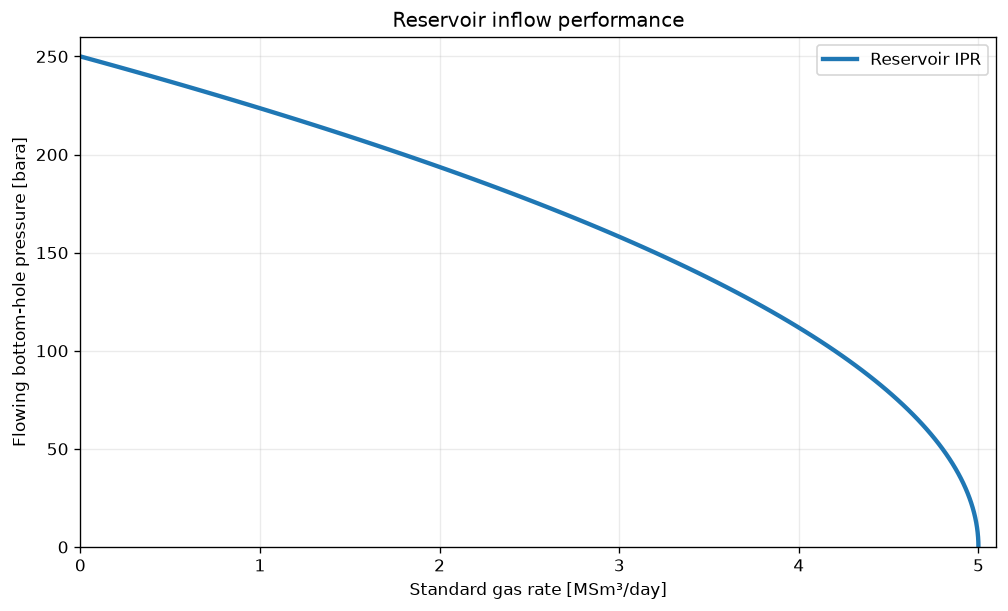

In [6]:
figure, axis = plt.subplots(figsize=(8.5, 5.2))
axis.plot(
    ipr_table["Rate [MSm³/day]"],
    ipr_table["IPR BHP [bara]"],
    linewidth=2.6,
    label="Reservoir IPR",
)
axis.set(
    title="Reservoir inflow performance",
    xlabel="Standard gas rate [MSm³/day]",
    ylabel="Flowing bottom-hole pressure [bara]",
    xlim=(0.0, 5.1),
    ylim=(0.0, 260.0),
)
axis.grid(alpha=0.25)
axis.legend()
figure.tight_layout()
plt.show()

## 6. Connected topside process

The topside includes:

1. HP three-phase separation;
2. HP-to-MP oil letdown and MP three-phase separation;
3. MP-to-LP oil letdown and LP three-phase separation;
4. LP and MP flash-gas recompression with aftercooling and scrubbers;
5. HP-gas mixing;
6. two-stage export compression with an interstage scrubber; and
7. export cooling and a final KO drum before the 160 bara market boundary.

Each scenario creates a fresh process. Streams are connected through NeqSim unit-operation
outlets rather than reconstructed from copied compositions.

In [7]:
def configure_compressor(
    name,
    inlet_stream,
    outlet_pressure_bara,
    efficiency,
):
    compressor = Compressor(name, inlet_stream)
    compressor.setOutletPressure(
        outlet_pressure_bara,
        "bara",
    )
    compressor.setUsePolytropicCalc(True)
    compressor.setPolytropicEfficiency(efficiency)
    return compressor


def build_topside_case(
    rate_msm3_day,
    hp_pressure_bara,
):
    feed = Stream(
        "topside arrival",
        make_fluid(
            rate_msm3_day,
            hp_pressure_bara,
            PROCESS_FEED_TEMPERATURE_C,
        ),
    )
    hp_separator = ThreePhaseSeparator(
        "HP separator",
        feed,
    )
    hp_oil_valve = ThrottlingValve(
        "HP-to-MP oil valve",
        hp_separator.getOilOutStream(),
    )
    hp_oil_valve.setOutletPressure(
        MP_PRESSURE_BARA,
        "bara",
    )
    mp_separator = ThreePhaseSeparator(
        "MP separator",
        hp_oil_valve.getOutletStream(),
    )
    mp_oil_valve = ThrottlingValve(
        "MP-to-LP oil valve",
        mp_separator.getOilOutStream(),
    )
    mp_oil_valve.setOutletPressure(
        LP_PRESSURE_BARA,
        "bara",
    )
    lp_separator = ThreePhaseSeparator(
        "LP separator",
        mp_oil_valve.getOutletStream(),
    )

    lp_compressor = configure_compressor(
        "LP recompressor",
        lp_separator.getGasOutStream(),
        MP_PRESSURE_BARA,
        0.75,
    )
    lp_cooler = Cooler(
        "LP aftercooler",
        lp_compressor.getOutletStream(),
    )
    lp_cooler.setOutTemperature(
        AFTERCOOLER_TEMPERATURE_C + 273.15
    )
    lp_scrubber = Separator(
        "LP compressor scrubber",
        lp_cooler.getOutletStream(),
    )

    mp_mixer = Mixer("MP gas mixer")
    mp_mixer.addStream(mp_separator.getGasOutStream())
    mp_mixer.addStream(lp_scrubber.getGasOutStream())
    mp_compressor = configure_compressor(
        "MP recompressor",
        mp_mixer.getOutletStream(),
        hp_pressure_bara,
        0.77,
    )
    mp_cooler = Cooler(
        "MP aftercooler",
        mp_compressor.getOutletStream(),
    )
    mp_cooler.setOutTemperature(
        AFTERCOOLER_TEMPERATURE_C + 273.15
    )
    mp_scrubber = Separator(
        "MP compressor scrubber",
        mp_cooler.getOutletStream(),
    )

    export_mixer = Mixer("export gas mixer")
    export_mixer.addStream(hp_separator.getGasOutStream())
    export_mixer.addStream(mp_scrubber.getGasOutStream())
    export_stage_1 = configure_compressor(
        "export compressor stage 1",
        export_mixer.getOutletStream(),
        EXPORT_INTERSTAGE_PRESSURE_BARA,
        0.79,
    )
    export_cooler_1 = Cooler(
        "export interstage cooler",
        export_stage_1.getOutletStream(),
    )
    export_cooler_1.setOutTemperature(
        AFTERCOOLER_TEMPERATURE_C + 273.15
    )
    export_scrubber = Separator(
        "export interstage scrubber",
        export_cooler_1.getOutletStream(),
    )
    export_stage_2 = configure_compressor(
        "export compressor stage 2",
        export_scrubber.getGasOutStream(),
        MARKET_PRESSURE_BARA,
        0.79,
    )
    export_cooler_2 = Cooler(
        "export aftercooler",
        export_stage_2.getOutletStream(),
    )
    export_cooler_2.setOutTemperature(
        AFTERCOOLER_TEMPERATURE_C + 273.15
    )
    export_ko = Separator(
        "export KO drum",
        export_cooler_2.getOutletStream(),
    )

    units = [
        feed,
        hp_separator,
        hp_oil_valve,
        mp_separator,
        mp_oil_valve,
        lp_separator,
        lp_compressor,
        lp_cooler,
        lp_scrubber,
        mp_mixer,
        mp_compressor,
        mp_cooler,
        mp_scrubber,
        export_mixer,
        export_stage_1,
        export_cooler_1,
        export_scrubber,
        export_stage_2,
        export_cooler_2,
        export_ko,
    ]
    process = ProcessSystem()
    for unit in units:
        process.add(unit)

    vessels = [
        hp_separator,
        mp_separator,
        lp_separator,
        lp_scrubber,
        mp_scrubber,
        export_scrubber,
        export_ko,
    ]
    compressors = [
        lp_compressor,
        mp_compressor,
        export_stage_1,
        export_stage_2,
    ]
    products = [
        lp_separator.getOilOutStream(),
        hp_separator.getWaterOutStream(),
        mp_separator.getWaterOutStream(),
        lp_separator.getWaterOutStream(),
        lp_scrubber.getLiquidOutStream(),
        mp_scrubber.getLiquidOutStream(),
        export_scrubber.getLiquidOutStream(),
        export_ko.getLiquidOutStream(),
        export_ko.getGasOutStream(),
    ]
    return {
        "process": process,
        "feed": feed,
        "vessels": vessels,
        "compressors": compressors,
        "products": products,
        "export_ko": export_ko,
    }

In [8]:
design_case = build_topside_case(
    DESIGN_RATE_MSM3_DAY,
    DESIGN_HP_PRESSURE_BARA,
)
design_case["process"].run()

feed_mass_kg_h = float(
    design_case["feed"].getFlowRate("kg/hr")
)
product_mass_kg_h = sum(
    float(product.getFlowRate("kg/hr"))
    for product in design_case["products"]
)
design_mass_residual = (
    product_mass_kg_h - feed_mass_kg_h
) / feed_mass_kg_h

process_summary = pd.DataFrame(
    {
        "Quantity": [
            "Feed mass rate",
            "Product mass rate",
            "Relative mass residual",
            "Export pressure",
            "Export temperature",
        ],
        "Value": [
            feed_mass_kg_h,
            product_mass_kg_h,
            design_mass_residual,
            design_case["export_ko"]
            .getGasOutStream()
            .getPressure("bara"),
            design_case["export_ko"]
            .getGasOutStream()
            .getTemperature("C"),
        ],
        "Unit": [
            "kg/h",
            "kg/h",
            "-",
            "bara",
            "°C",
        ],
    }
)
display(process_summary)

                 Quantity         Value  Unit
0          Feed mass rate  1.411499e+05  kg/h
1       Product mass rate  1.411499e+05  kg/h
2  Relative mass residual -2.259852e-13     -
3         Export pressure  1.600000e+02  bara
4      Export temperature  3.500000e+01    °C


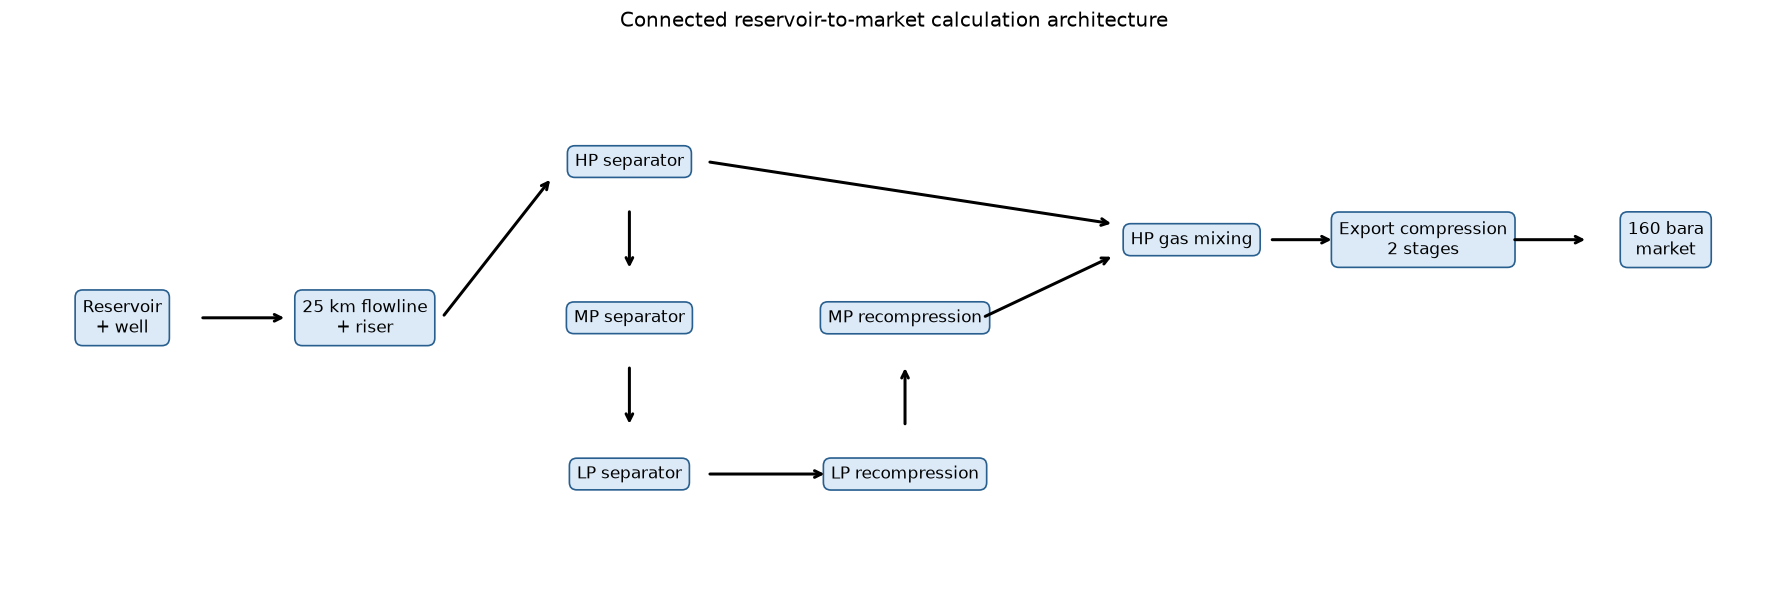

In [9]:
figure, axis = plt.subplots(figsize=(15.0, 5.2))
blocks = [
    (0.0, 1.8, "Reservoir\n+ well"),
    (2.2, 1.8, "25 km flowline\n+ riser"),
    (4.6, 2.8, "HP separator"),
    (4.6, 1.8, "MP separator"),
    (4.6, 0.8, "LP separator"),
    (7.1, 0.8, "LP recompression"),
    (7.1, 1.8, "MP recompression"),
    (9.7, 2.3, "HP gas mixing"),
    (11.8, 2.3, "Export compression\n2 stages"),
    (14.0, 2.3, "160 bara\nmarket"),
]
for x_position, y_position, label in blocks:
    axis.text(
        x_position,
        y_position,
        label,
        ha="center",
        va="center",
        bbox={
            "boxstyle": "round,pad=0.45",
            "facecolor": "#dceaf7",
            "edgecolor": "#285f8f",
        },
    )
arrows = [
    ((0.7, 1.8), (1.5, 1.8)),
    ((2.9, 1.8), (3.9, 2.7)),
    ((4.6, 2.5), (4.6, 2.1)),
    ((4.6, 1.5), (4.6, 1.1)),
    ((5.3, 0.8), (6.4, 0.8)),
    ((7.1, 1.1), (7.1, 1.5)),
    ((7.8, 1.8), (9.0, 2.2)),
    ((5.3, 2.8), (9.0, 2.4)),
    ((10.4, 2.3), (11.0, 2.3)),
    ((12.6, 2.3), (13.3, 2.3)),
]
for start, end in arrows:
    axis.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops={"arrowstyle": "->", "lw": 1.8},
    )
axis.set(
    title="Connected reservoir-to-market calculation architecture",
    xlim=(-1.0, 15.0),
    ylim=(0.0, 3.6),
)
axis.axis("off")
figure.tight_layout()
plt.show()

## 7. Mechanical design and installed vessel dimensions

NeqSim mechanical design supplies an initial inner diameter and tan-to-tan length.
Installed dimensions are rounded upward and then enlarged until every live capacity
constraint is below the 80% design target.

Gas-controlled constraints scale approximately with cross-sectional area,

$$
U_{\mathrm{gas}}
\propto
\frac{q_{\mathrm{actual}}}{D^2},
$$

while retention constraints scale with available liquid volume,

$$
U_{\mathrm{retention}}
\propto
\frac{q_{\mathrm{liquid}}}{D^2L}.
$$

The loop uses the native calculated utilization rather than assuming these proportional
relations are exact.

In [10]:
def round_up(value, increment):
    return math.ceil(value / increment) * increment


def configure_vessel_constraints(vessel):
    vessel.clearCapacityConstraints()
    vessel.setCapacityAnalysisEnabled(True)
    name = str(vessel.getName()).lower()
    if "scrubber" in name or "ko drum" in name:
        vessel.useGasScrubberConstraints()
    else:
        vessel.useGasCapacityConstraints()
        vessel.useLiquidCapacityConstraints()


def constraint_utilizations(vessel):
    return {
        str(entry.getKey()): float(
            entry.getValue().getUtilization()
        )
        for entry in vessel.getCapacityConstraints().entrySet()
    }


required_design_rows = []
for vessel in design_case["vessels"]:
    mechanical_design = vessel.getMechanicalDesign()
    mechanical_design.calcDesign()
    required_design_rows.append(
        {
            "Equipment": str(vessel.getName()),
            "Required diameter [m]": float(
                mechanical_design.getInnerDiameter()
            ),
            "Required length [m]": float(
                mechanical_design.getTantanLength()
            ),
        }
    )
    installed_diameter = round_up(
        1.10 * float(
            mechanical_design.getInnerDiameter()
        ),
        0.1,
    )
    installed_length = round_up(
        max(
            1.10 * float(
                mechanical_design.getTantanLength()
            ),
            3.0 * installed_diameter,
        ),
        0.5,
    )
    vessel.setInternalDiameter(installed_diameter)
    vessel.setSeparatorLength(installed_length)
    vessel.setInletPipeDiameter(
        max(0.1, 0.30 * installed_diameter)
    )
    configure_vessel_constraints(vessel)

for sizing_iteration in range(8):
    design_case["process"].run()
    changed = False
    for vessel in design_case["vessels"]:
        gas_max = 0.0
        retention_max = 0.0
        for name, utilization in (
            constraint_utilizations(vessel).items()
        ):
            if "Retention" in name:
                retention_max = max(
                    retention_max,
                    utilization,
                )
            else:
                gas_max = max(gas_max, utilization)

        diameter = float(vessel.getInternalDiameter())
        length = float(vessel.getSeparatorLength())
        if gas_max > VESSEL_DESIGN_UTILIZATION * 1.001:
            diameter = round_up(
                diameter
                * min(
                    math.sqrt(
                        gas_max
                        / VESSEL_DESIGN_UTILIZATION
                    ),
                    2.5,
                ),
                0.1,
            )
            changed = True
        if (
            retention_max
            > VESSEL_DESIGN_UTILIZATION * 1.001
        ):
            length = round_up(
                length
                * min(
                    retention_max
                    / VESSEL_DESIGN_UTILIZATION,
                    3.0,
                ),
                0.5,
            )
            changed = True
        length = max(length, 3.0 * diameter)
        vessel.setInternalDiameter(diameter)
        vessel.setSeparatorLength(length)
        vessel.setInletPipeDiameter(
            max(0.1, 0.30 * diameter)
        )
    if not changed:
        break

design_case["process"].run()
vessel_specs = {
    str(vessel.getName()): {
        "diameter_m": float(
            vessel.getInternalDiameter()
        ),
        "length_m": float(
            vessel.getSeparatorLength()
        ),
    }
    for vessel in design_case["vessels"]
}

In [11]:
required_design = pd.DataFrame(required_design_rows)
installed_rows = []
vessel_constraint_rows = []
for vessel in design_case["vessels"]:
    name = str(vessel.getName())
    utilizations = constraint_utilizations(vessel)
    installed_rows.append(
        {
            "Equipment": name,
            "Installed diameter [m]": (
                vessel_specs[name]["diameter_m"]
            ),
            "Installed length [m]": (
                vessel_specs[name]["length_m"]
            ),
            "Maximum utilization [%]": (
                100.0 * max(utilizations.values())
            ),
        }
    )
    for constraint, utilization in utilizations.items():
        vessel_constraint_rows.append(
            {
                "Equipment": name,
                "Constraint": constraint,
                "Utilization [%]": 100.0 * utilization,
            }
        )

vessel_design_table = required_design.merge(
    pd.DataFrame(installed_rows),
    on="Equipment",
)
vessel_constraint_table = pd.DataFrame(
    vessel_constraint_rows
)
display(vessel_design_table.round(3))
display(
    vessel_constraint_table.pivot(
        index="Equipment",
        columns="Constraint",
        values="Utilization [%]",
    ).round(2)
)

                    Equipment  ...  Maximum utilization [%]
0                HP separator  ...                   79.616
1                MP separator  ...                   78.616
2                LP separator  ...                   79.139
3      LP compressor scrubber  ...                   51.470
4      MP compressor scrubber  ...                   67.034
5  export interstage scrubber  ...                   75.854
6              export KO drum  ...                   75.351

[7 rows x 6 columns]
Constraint                  dropletCutSize  ...  waterRetentionTime
Equipment                                   ...                    
HP separator                         25.10  ...                0.68
LP compressor scrubber               16.96  ...                0.06
LP separator                         16.88  ...                0.30
MP compressor scrubber               16.17  ...                0.17
MP separator                         10.18  ...                0.30
export KO drum        

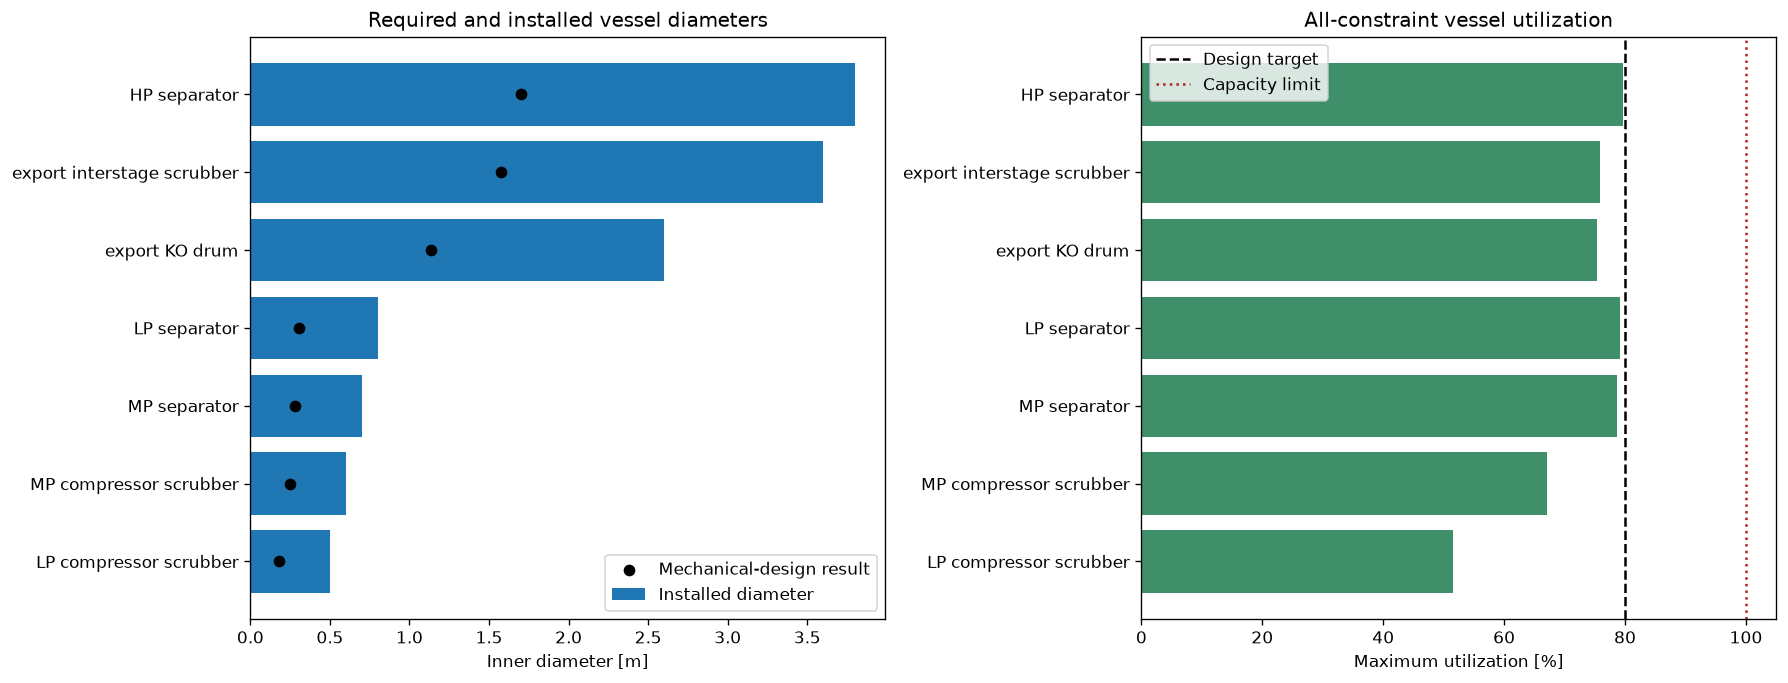

In [12]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(15.0, 5.8),
)
vessel_plot = vessel_design_table.sort_values(
    "Installed diameter [m]"
)
axes[0].barh(
    vessel_plot["Equipment"],
    vessel_plot["Installed diameter [m]"],
    label="Installed diameter",
)
axes[0].scatter(
    vessel_plot["Required diameter [m]"],
    vessel_plot["Equipment"],
    color="black",
    label="Mechanical-design result",
    zorder=3,
)
axes[0].set(
    title="Required and installed vessel diameters",
    xlabel="Inner diameter [m]",
)
axes[0].legend()

axes[1].barh(
    vessel_plot["Equipment"],
    vessel_plot["Maximum utilization [%]"],
    color="#3f8f6b",
)
axes[1].axvline(
    80.0,
    color="black",
    linestyle="--",
    label="Design target",
)
axes[1].axvline(
    100.0,
    color="firebrick",
    linestyle=":",
    label="Capacity limit",
)
axes[1].set(
    title="All-constraint vessel utilization",
    xlabel="Maximum utilization [%]",
)
axes[1].legend()
figure.tight_layout()
plt.show()

## 8. Generate complete compressor maps

Each NeqSim `CompressorChartGenerator` map has seven speed lines and five points per line.
The first point of each line is surge; the last is stonewall. Reynolds, Mach, and
multistage corrections are enabled where applicable.

For a scenario, the required process head and actual suction flow are projected onto the
fixed design map. If the process flow is left of the 10% anti-surge control line, the
internal compressor flow is raised by recycle. The adjusted driver load is approximated as

$$
P_{\mathrm{recycle}}
=
P_{\mathrm{once-through}}
\frac{Q_{\mathrm{internal}}}{Q_{\mathrm{process}}}.
$$

This is a steady-state screening relation, not a dynamic anti-surge controller model.

In [13]:
map_diameters_m = {
    "LP recompressor": 0.45,
    "MP recompressor": 0.60,
    "export compressor stage 1": 0.85,
    "export compressor stage 2": 0.75,
}
compressor_charts = {}
driver_ratings_kw = {}
map_rows = []

for compressor in design_case["compressors"]:
    name = str(compressor.getName())
    generator = CompressorChartGenerator(compressor)
    generator.setChartType("interpolate and extrapolate")
    generator.setImpellerDiameter(map_diameters_m[name])
    generator.enableAdvancedCorrections(
        1 if name == "LP recompressor" else 2
    )
    chart = generator.generateCompressorChart(
        "normal curves",
        7,
    )
    compressor_charts[name] = chart
    driver_ratings_kw[name] = round_up(
        1.25 * float(compressor.getPower("kW")),
        100.0,
    )

    speeds = [float(value) for value in chart.getSpeeds()]
    flows = chart.getFlows()
    heads = chart.getHeads()
    efficiencies = chart.getPolytropicEfficiencies()
    for curve_index, speed_rpm in enumerate(speeds):
        for point_index in range(
            len(flows[curve_index])
        ):
            if point_index == 0:
                position = "surge"
            elif (
                point_index
                == len(flows[curve_index]) - 1
            ):
                position = "stonewall"
            else:
                position = "interior"
            map_rows.append(
                {
                    "Compressor": name,
                    "Speed [rpm]": speed_rpm,
                    "Point": point_index,
                    "Position": position,
                    "Flow [m³/h]": float(
                        flows[curve_index][point_index]
                    ),
                    "Head [kJ/kg]": float(
                        heads[curve_index][point_index]
                    ),
                    "Efficiency [%]": float(
                        efficiencies[curve_index][
                            point_index
                        ]
                    ),
                }
            )

compressor_map_table = pd.DataFrame(map_rows)
driver_table = pd.DataFrame(
    {
        "Compressor": list(driver_ratings_kw),
        "Installed driver [kW]": list(
            driver_ratings_kw.values()
        ),
    }
)
display(driver_table)
print(
    "Generated map points:",
    len(compressor_map_table),
)

                  Compressor  Installed driver [kW]
0            LP recompressor                  100.0
1            MP recompressor                  200.0
2  export compressor stage 1                 3100.0
3  export compressor stage 2                 2300.0
Generated map points: 140


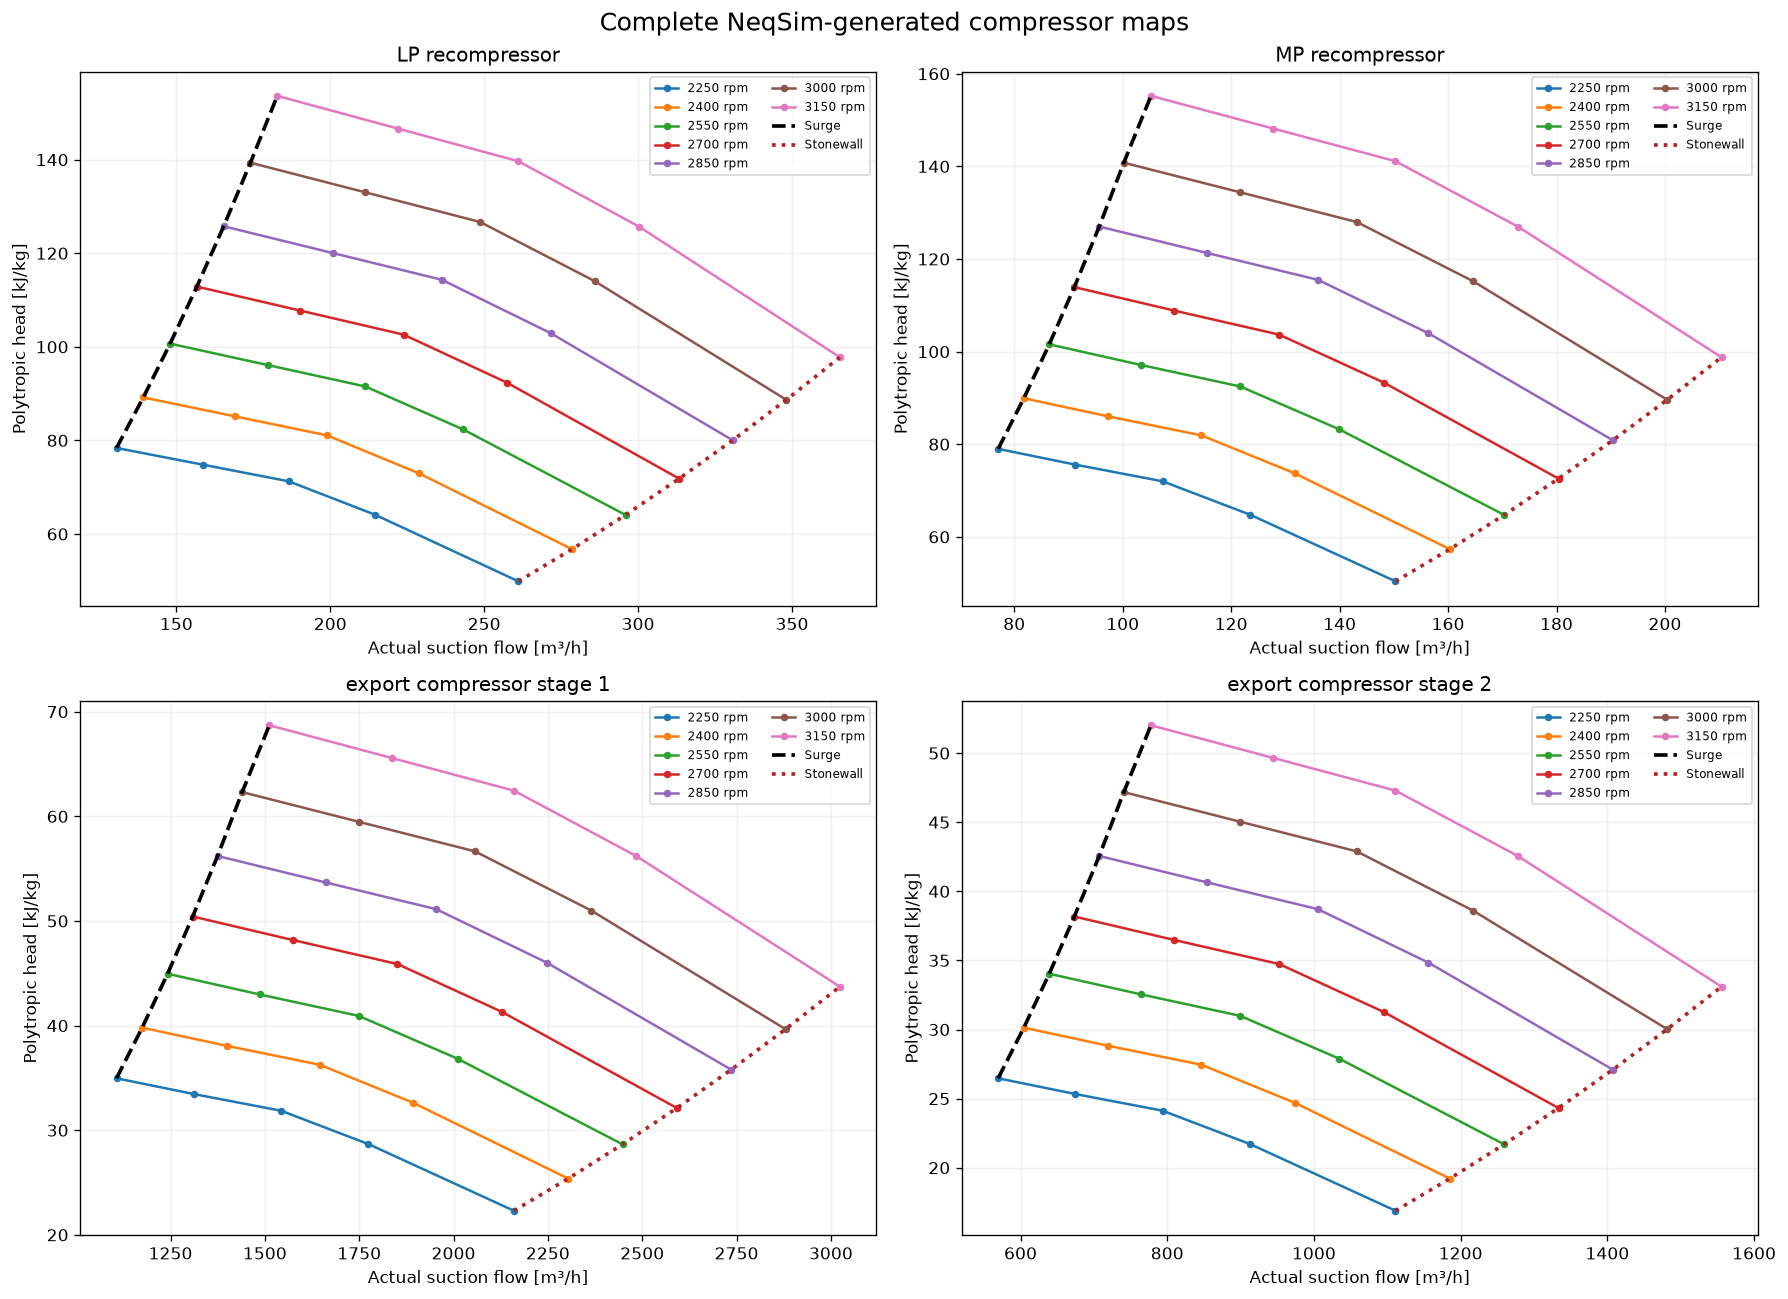

In [14]:
figure, axes = plt.subplots(
    2,
    2,
    figsize=(15.0, 11.0),
)
for axis, compressor_name in zip(
    axes.ravel(),
    compressor_charts,
):
    machine_data = compressor_map_table[
        compressor_map_table["Compressor"]
        == compressor_name
    ]
    for speed_rpm, speed_data in machine_data.groupby(
        "Speed [rpm]"
    ):
        axis.plot(
            speed_data["Flow [m³/h]"],
            speed_data["Head [kJ/kg]"],
            marker="o",
            markersize=3.5,
            label=f"{speed_rpm:.0f} rpm",
        )
    surge = machine_data[
        machine_data["Position"] == "surge"
    ]
    stonewall = machine_data[
        machine_data["Position"] == "stonewall"
    ]
    axis.plot(
        surge["Flow [m³/h]"],
        surge["Head [kJ/kg]"],
        "k--",
        linewidth=2.2,
        label="Surge",
    )
    axis.plot(
        stonewall["Flow [m³/h]"],
        stonewall["Head [kJ/kg]"],
        color="firebrick",
        linestyle=":",
        linewidth=2.2,
        label="Stonewall",
    )
    axis.set(
        title=compressor_name,
        xlabel="Actual suction flow [m³/h]",
        ylabel="Polytropic head [kJ/kg]",
    )
    axis.grid(alpha=0.2)
    axis.legend(ncol=2, fontsize=7)
figure.suptitle(
    "Complete NeqSim-generated compressor maps",
    fontsize=15,
)
figure.tight_layout()
plt.show()

## 9. Unified equipment-capacity evaluation

The next functions apply the fixed installed vessel dimensions to every fresh scenario and
calculate a unified utilization. For vessels this is the maximum native NeqSim constraint.
For compressors it is the maximum of adjusted driver power, maximum speed, stonewall,
and the permitted recycle fraction. The limiting equipment is retained explicitly.

In [15]:
def apply_installed_vessels(
    case,
    vessel_diameter_scale=1.0,
    vessel_length_scale=1.0,
):
    for vessel in case["vessels"]:
        name = str(vessel.getName())
        specification = vessel_specs[name]
        vessel.setInternalDiameter(
            vessel_diameter_scale
            * specification["diameter_m"]
        )
        vessel.setSeparatorLength(
            vessel_length_scale
            * specification["length_m"]
        )
        vessel.setInletPipeDiameter(
            max(
                0.1,
                0.30
                * vessel_diameter_scale
                * specification["diameter_m"],
            )
        )
        configure_vessel_constraints(vessel)


def compressor_map_point(
    compressor,
    chart,
    map_flow_scale=1.0,
):
    process_flow = float(
        compressor.getInletStream().getFlowRate("m3/hr")
    )
    head = float(
        compressor.getPolytropicHead("kJ/kg")
    )
    internal_flow = process_flow
    for _ in range(12):
        speed = float(
            chart.getSpeedValue(
                internal_flow / map_flow_scale,
                head,
            )
        )
        surge_flow = float(
            chart.getSurgeFlowAtSpeed(speed)
        ) * map_flow_scale
        control_flow = 1.10 * surge_flow
        if internal_flow >= control_flow:
            break
        internal_flow = control_flow

    speed = float(
        chart.getSpeedValue(
            internal_flow / map_flow_scale,
            head,
        )
    )
    surge_flow = float(
        chart.getSurgeFlowAtSpeed(speed)
    ) * map_flow_scale
    stonewall_flow = float(
        chart.getStoneWallFlowAtSpeed(speed)
    ) * map_flow_scale
    recycle_fraction = max(
        0.0,
        (internal_flow - process_flow) / process_flow,
    )
    return {
        "process_flow_m3_h": process_flow,
        "internal_flow_m3_h": internal_flow,
        "head_kj_kg": head,
        "speed_rpm": speed,
        "surge_flow_m3_h": surge_flow,
        "stonewall_flow_m3_h": stonewall_flow,
        "recycle_fraction": recycle_fraction,
    }

In [16]:
def evaluate_topside(
    rate_msm3_day,
    hp_pressure_bara,
    vessel_diameter_scale=1.0,
    vessel_length_scale=1.0,
    compressor_map_flow_scale=1.0,
    driver_rating_scale=1.0,
):
    case = build_topside_case(
        rate_msm3_day,
        hp_pressure_bara,
    )
    apply_installed_vessels(
        case,
        vessel_diameter_scale,
        vessel_length_scale,
    )
    case["process"].setCapacityAnalysisEnabled(True)
    case["process"].run()

    feed_mass = float(
        case["feed"].getFlowRate("kg/hr")
    )
    product_mass = sum(
        float(product.getFlowRate("kg/hr"))
        for product in case["products"]
    )
    mass_residual = (product_mass - feed_mass) / feed_mass
    equipment_rows = []

    for vessel in case["vessels"]:
        utilization = float(
            vessel.getCapacityUtilization()
        )
        equipment_rows.append(
            {
                "Equipment": str(vessel.getName()),
                "Equipment type": "Vessel",
                "Utilization": utilization,
                "Recycle fraction": 0.0,
                "Power [kW]": 0.0,
                "Speed [rpm]": 0.0,
            }
        )

    for compressor in case["compressors"]:
        name = str(compressor.getName())
        point = compressor_map_point(
            compressor,
            compressor_charts[name],
            compressor_map_flow_scale,
        )
        adjusted_power = (
            float(compressor.getPower("kW"))
            * (
                1.0
                + point["recycle_fraction"]
            )
        )
        power_utilization = (
            adjusted_power
            / (
                driver_rating_scale
                * driver_ratings_kw[name]
            )
        )
        speed_utilization = (
            point["speed_rpm"]
            / float(
                compressor_charts[name]
                .getMaxSpeedCurve()
            )
        )
        stonewall_utilization = (
            point["internal_flow_m3_h"]
            / point["stonewall_flow_m3_h"]
        )
        recycle_utilization = (
            point["recycle_fraction"]
            / MAX_RECYCLE_FRACTION
        )
        utilization = max(
            power_utilization,
            speed_utilization,
            stonewall_utilization,
            recycle_utilization,
        )
        equipment_rows.append(
            {
                "Equipment": name,
                "Equipment type": "Compressor",
                "Utilization": utilization,
                "Recycle fraction": (
                    point["recycle_fraction"]
                ),
                "Power [kW]": adjusted_power,
                "Speed [rpm]": point["speed_rpm"],
            }
        )

    limiting = max(
        equipment_rows,
        key=lambda row: row["Utilization"],
    )
    export_pressure = float(
        case["export_ko"]
        .getGasOutStream()
        .getPressure("bara")
    )
    feasible = (
        limiting["Utilization"] <= 1.0
        and abs(
            export_pressure - MARKET_PRESSURE_BARA
        )
        <= 0.05
        and abs(mass_residual) <= 1.0e-6
    )
    return {
        "Rate [MSm³/day]": rate_msm3_day,
        "HP pressure [bara]": hp_pressure_bara,
        "Feasible": feasible,
        "Maximum utilization": (
            limiting["Utilization"]
        ),
        "Limiting equipment": limiting["Equipment"],
        "Export pressure [bara]": export_pressure,
        "Mass residual": mass_residual,
        "Equipment rows": equipment_rows,
    }

## 10. Optimize process pressure and calculate maximum capacity

Rates from 0.75 to 4.75 MSm³/day and HP pressures from 55 to 75 bara are screened. The
lowest feasible HP pressure is selected because it gives the well the lowest downstream
backpressure. If no pressure is feasible, the least-utilized case is retained only to show
the excluded part of the system curve.

In [17]:
process_rate_grid = np.arange(0.75, 4.76, 0.25)
hp_pressure_candidates = np.array(
    [55.0, 60.0, 65.0, 70.0, 75.0]
)
scenario_results = []
for rate_msm3_day in process_rate_grid:
    for hp_pressure_bara in hp_pressure_candidates:
        try:
            result = evaluate_topside(
                float(rate_msm3_day),
                float(hp_pressure_bara),
            )
        except Exception as error:
            result = {
                "Rate [MSm³/day]": float(
                    rate_msm3_day
                ),
                "HP pressure [bara]": float(
                    hp_pressure_bara
                ),
                "Feasible": False,
                "Maximum utilization": np.inf,
                "Limiting equipment": (
                    f"Simulation failure: {error}"
                ),
                "Export pressure [bara]": np.nan,
                "Mass residual": np.nan,
                "Equipment rows": [],
            }
        scenario_results.append(result)

scenario_table = pd.DataFrame(
    [
        {
            key: value
            for key, value in result.items()
            if key != "Equipment rows"
        }
        for result in scenario_results
    ]
)
feasible_scenarios = scenario_table[
    scenario_table["Feasible"]
].copy()
if feasible_scenarios.empty:
    raise RuntimeError(
        "No feasible topside operating scenario."
    )

optimal_process_rows = []
for rate_msm3_day, group in scenario_table.groupby(
    "Rate [MSm³/day]"
):
    feasible_group = group[group["Feasible"]]
    if not feasible_group.empty:
        selected = feasible_group.sort_values(
            "HP pressure [bara]"
        ).iloc[0]
    else:
        selected = group.sort_values(
            "Maximum utilization"
        ).iloc[0]
    optimal_process_rows.append(selected)

optimal_process_table = pd.DataFrame(
    optimal_process_rows
).sort_values("Rate [MSm³/day]")
topside_capacity_msm3_day = float(
    feasible_scenarios["Rate [MSm³/day]"].max()
)

display(
    optimal_process_table[
        [
            "Rate [MSm³/day]",
            "HP pressure [bara]",
            "Feasible",
            "Maximum utilization",
            "Limiting equipment",
        ]
    ].round(4)
)
print(
    "Maximum screened topside rate:",
    f"{topside_capacity_msm3_day:.3f} MSm³/day",
)

    Rate [MSm³/day]  ...         Limiting equipment
2              0.75  ...            MP recompressor
7              1.00  ...  export compressor stage 2
12             1.25  ...  export compressor stage 1
17             1.50  ...  export compressor stage 1
22             1.75  ...  export compressor stage 2
27             2.00  ...  export compressor stage 1
32             2.25  ...  export compressor stage 1
37             2.50  ...  export compressor stage 2
42             2.75  ...            LP recompressor
47             3.00  ...  export compressor stage 2
52             3.25  ...  export compressor stage 2
57             3.50  ...            LP recompressor
62             3.75  ...  export compressor stage 2
67             4.00  ...            MP recompressor
72             4.25  ...            LP recompressor
77             4.50  ...  export compressor stage 1
82             4.75  ...            LP recompressor

[17 rows x 5 columns]
Maximum screened topside rate: 4.000 MSm³

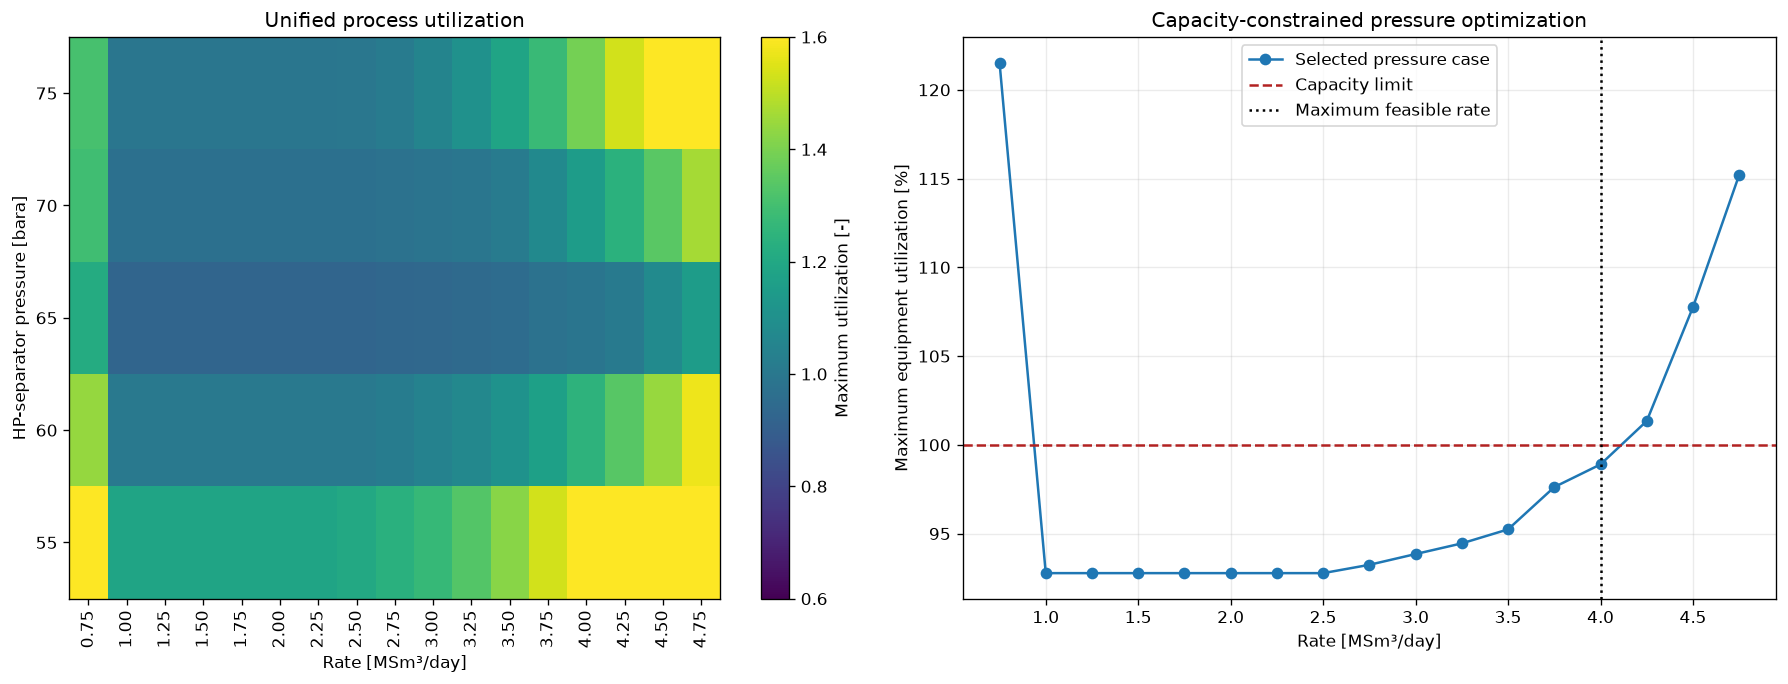

In [18]:
utilization_surface = scenario_table.pivot(
    index="HP pressure [bara]",
    columns="Rate [MSm³/day]",
    values="Maximum utilization",
)
plot_surface = utilization_surface.replace(
    [np.inf, -np.inf],
    np.nan,
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(15.0, 5.8),
)
image = axes[0].imshow(
    plot_surface.to_numpy(),
    aspect="auto",
    origin="lower",
    cmap="viridis",
    vmin=0.6,
    vmax=1.6,
)
axes[0].set(
    title="Unified process utilization",
    xlabel="Rate [MSm³/day]",
    ylabel="HP-separator pressure [bara]",
    xticks=np.arange(len(plot_surface.columns)),
    yticks=np.arange(len(plot_surface.index)),
    xticklabels=[
        f"{value:.2f}"
        for value in plot_surface.columns
    ],
    yticklabels=[
        f"{value:.0f}"
        for value in plot_surface.index
    ],
)
axes[0].tick_params(axis="x", rotation=90)
figure.colorbar(
    image,
    ax=axes[0],
    label="Maximum utilization [-]",
)

axes[1].plot(
    optimal_process_table["Rate [MSm³/day]"],
    100.0
    * optimal_process_table["Maximum utilization"],
    marker="o",
    label="Selected pressure case",
)
axes[1].axhline(
    100.0,
    color="firebrick",
    linestyle="--",
    label="Capacity limit",
)
axes[1].axvline(
    topside_capacity_msm3_day,
    color="black",
    linestyle=":",
    label="Maximum feasible rate",
)
axes[1].set(
    title="Capacity-constrained pressure optimization",
    xlabel="Rate [MSm³/day]",
    ylabel="Maximum equipment utilization [%]",
)
axes[1].grid(alpha=0.25)
axes[1].legend()
figure.tight_layout()
plt.show()

## 11. Gathering-system lift requirement

A NeqSim `PipeBeggsAndBrills` flowline is solved repeatedly. For each rate and selected HP
pressure, bisection finds the wellhead pressure that reproduces the topside arrival
boundary. Failures at a trial pressure are treated as a lower-bound pressure, not silently
accepted.

In [19]:
def flowline_outlet_pressure(
    rate_msm3_day,
    wellhead_pressure_bara,
    flowline_diameter_m=FLOWLINE_DIAMETER_M,
):
    fluid = make_fluid(
        rate_msm3_day,
        wellhead_pressure_bara,
        70.0,
    )
    wellhead_stream = Stream("wellhead stream", fluid)
    flowline = PipeBeggsAndBrills(
        "subsea flowline and riser",
        wellhead_stream,
    )
    flowline.setDiameter(flowline_diameter_m)
    flowline.setPipeWallRoughness(
        FLOWLINE_ROUGHNESS_M
    )
    flowline.setLength(FLOWLINE_LENGTH_M)
    flowline.setElevation(FLOWLINE_ELEVATION_M)
    flowline.setAngle(0.0)
    flowline.setNumberOfIncrements(24)
    flowline.run()
    return float(
        flowline.getOutStream().getPressure("bara")
    )


def required_wellhead_pressure(
    rate_msm3_day,
    arrival_pressure_bara,
    flowline_diameter_m=FLOWLINE_DIAMETER_M,
):
    lower = arrival_pressure_bara + 0.05
    upper = RESERVOIR_PRESSURE_BARA - 0.5
    for _ in range(28):
        middle = 0.5 * (lower + upper)
        try:
            outlet = flowline_outlet_pressure(
                rate_msm3_day,
                middle,
                flowline_diameter_m,
            )
        except Exception:
            outlet = -np.inf
        if outlet < arrival_pressure_bara:
            lower = middle
        else:
            upper = middle
    return 0.5 * (lower + upper)


system_rows = []
for _, process_row in optimal_process_table.iterrows():
    rate = float(process_row["Rate [MSm³/day]"])
    arrival_pressure = float(
        process_row["HP pressure [bara]"]
    )
    wellhead_pressure = required_wellhead_pressure(
        rate,
        arrival_pressure,
    )
    well = make_well(
        tubing_head_pressure_bara=wellhead_pressure
    )
    vlp_curve = np.asarray(
        well.generateVLPCurve(
            np.array([rate * 1.0e6])
        ),
        dtype=float,
    )
    system_rows.append(
        {
            "Rate [MSm³/day]": rate,
            "IPR BHP [bara]": ipr_pressure(rate),
            "System BHP [bara]": float(
                vlp_curve[1, 0]
            ),
            "Required WHP [bara]": wellhead_pressure,
            "HP arrival [bara]": arrival_pressure,
            "Flowline loss [bar]": (
                wellhead_pressure - arrival_pressure
            ),
            "Process feasible": bool(
                process_row["Feasible"]
            ),
            "Maximum utilization": float(
                process_row["Maximum utilization"]
            ),
            "Limiting equipment": str(
                process_row["Limiting equipment"]
            ),
        }
    )

system_curve_table = pd.DataFrame(system_rows)
system_curve_table["Pressure residual [bar]"] = (
    system_curve_table["IPR BHP [bara]"]
    - system_curve_table["System BHP [bara]"]
)
display(system_curve_table.round(4))

    Rate [MSm³/day]  ...  Pressure residual [bar]
0              0.75  ...                 113.5259
1              1.00  ...                 103.3650
2              1.25  ...                  91.1704
3              1.50  ...                  77.6398
4              1.75  ...                  63.0655
5              2.00  ...                  47.8856
6              2.25  ...                  31.7760
7              2.50  ...                  14.7013
8              2.75  ...                  -3.3440
9              3.00  ...                 -22.3884
10             3.25  ...                 -42.4910
11             3.50  ...                 -63.7531
12             3.75  ...                 -86.3417
13             4.00  ...                -110.5344
14             4.25  ...                -136.8217
15             4.50  ...                -166.1871
16             4.75  ...                -201.2074

[17 rows x 10 columns]


## 12. Find the reservoir-to-market operating point

The curve intersection is found from a sign change in the pressure residual. Bisection is
then applied to the piecewise-linear calculated curves. The final rate is additionally
clipped by the maximum feasible topside rate.

In [20]:
feasible_system = system_curve_table[
    system_curve_table["Process feasible"]
].copy()
residual = feasible_system[
    "Pressure residual [bar]"
].to_numpy()
rates = feasible_system["Rate [MSm³/day]"].to_numpy()
crossing_indices = np.where(
    residual[:-1] * residual[1:] <= 0.0
)[0]
if len(crossing_indices) != 1:
    raise RuntimeError(
        "Expected one feasible reservoir-to-market crossing."
    )

lower_rate = float(rates[crossing_indices[0]])
upper_rate = float(rates[crossing_indices[0] + 1])

def interpolated_pressure_residual(rate):
    ipr_value = np.interp(
        rate,
        system_curve_table["Rate [MSm³/day]"],
        system_curve_table["IPR BHP [bara]"],
    )
    system_value = np.interp(
        rate,
        system_curve_table["Rate [MSm³/day]"],
        system_curve_table["System BHP [bara]"],
    )
    return float(ipr_value - system_value)


for _ in range(50):
    middle_rate = 0.5 * (
        lower_rate + upper_rate
    )
    if (
        interpolated_pressure_residual(lower_rate)
        * interpolated_pressure_residual(middle_rate)
        <= 0.0
    ):
        upper_rate = middle_rate
    else:
        lower_rate = middle_rate

curve_crossing_rate = 0.5 * (
    lower_rate + upper_rate
)
operating_rate_msm3_day = min(
    curve_crossing_rate,
    topside_capacity_msm3_day,
)
operating_bhp_bara = float(
    np.interp(
        operating_rate_msm3_day,
        system_curve_table["Rate [MSm³/day]"],
        system_curve_table["System BHP [bara]"],
    )
)
operating_whp_bara = float(
    np.interp(
        operating_rate_msm3_day,
        system_curve_table["Rate [MSm³/day]"],
        system_curve_table["Required WHP [bara]"],
    )
)
crossing_residual_bar = (
    interpolated_pressure_residual(
        curve_crossing_rate
    )
)

operating_summary = pd.DataFrame(
    {
        "Quantity": [
            "Unconstrained curve crossing",
            "Topside capacity",
            "Capacity-constrained operating rate",
            "Operating BHP",
            "Required operating WHP",
            "Interpolated pressure residual",
        ],
        "Value": [
            curve_crossing_rate,
            topside_capacity_msm3_day,
            operating_rate_msm3_day,
            operating_bhp_bara,
            operating_whp_bara,
            crossing_residual_bar,
        ],
        "Unit": [
            "MSm³/day",
            "MSm³/day",
            "MSm³/day",
            "bara",
            "bara",
            "bar",
        ],
    }
)
display(operating_summary)

                              Quantity         Value      Unit
0         Unconstrained curve crossing  2.703673e+00  MSm³/day
1                     Topside capacity  4.000000e+00  MSm³/day
2  Capacity-constrained operating rate  2.703673e+00  MSm³/day
3                        Operating BHP  1.693861e+02      bara
4               Required operating WHP  8.771985e+01      bara
5       Interpolated pressure residual  2.842171e-14       bar


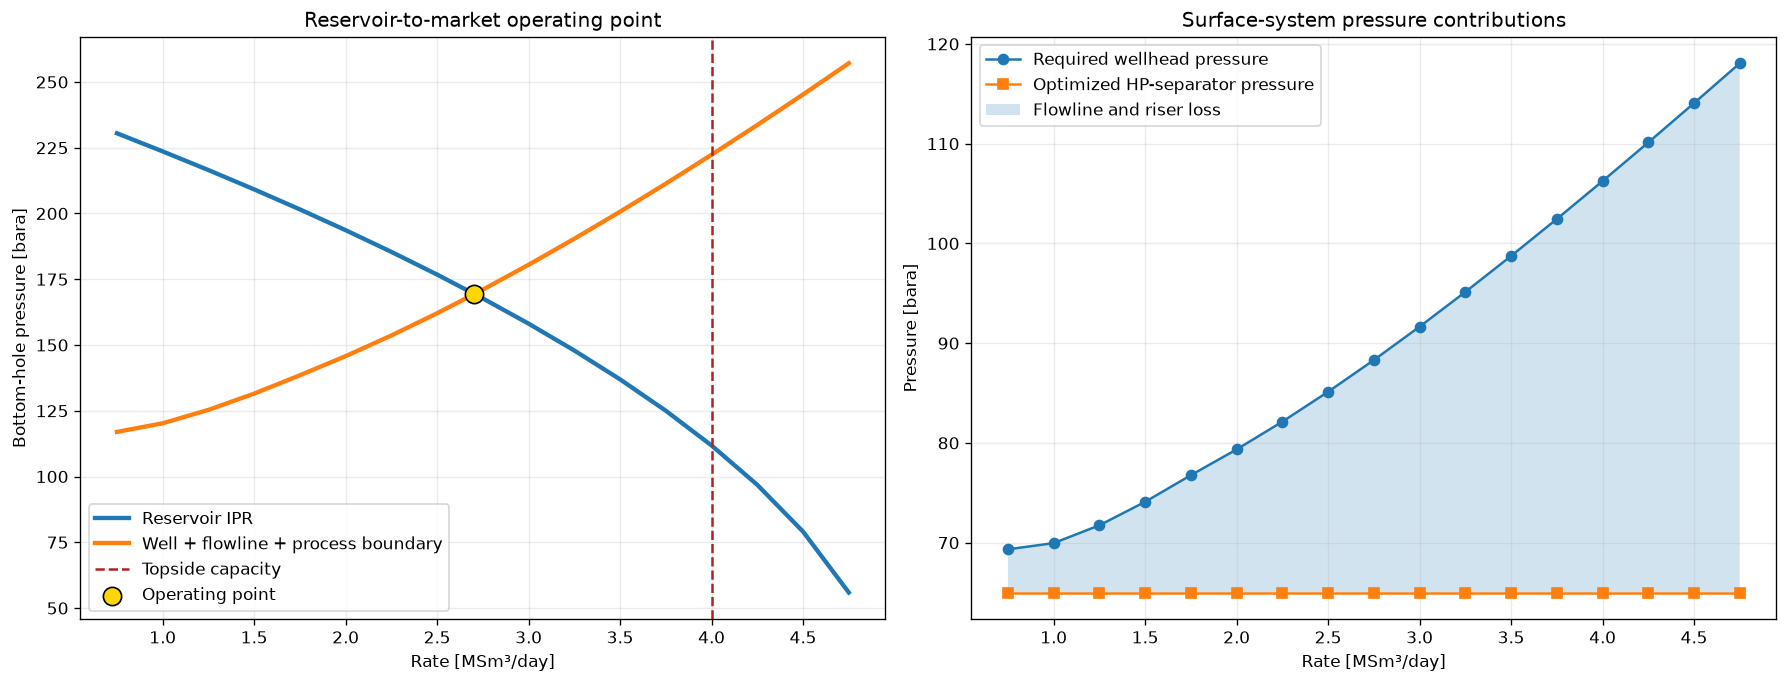

In [21]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(15.0, 5.8),
)
axes[0].plot(
    system_curve_table["Rate [MSm³/day]"],
    system_curve_table["IPR BHP [bara]"],
    linewidth=2.6,
    label="Reservoir IPR",
)
axes[0].plot(
    system_curve_table["Rate [MSm³/day]"],
    system_curve_table["System BHP [bara]"],
    linewidth=2.6,
    label="Well + flowline + process boundary",
)
axes[0].axvline(
    topside_capacity_msm3_day,
    color="firebrick",
    linestyle="--",
    label="Topside capacity",
)
axes[0].scatter(
    [operating_rate_msm3_day],
    [operating_bhp_bara],
    s=120,
    color="gold",
    edgecolor="black",
    label="Operating point",
    zorder=5,
)
axes[0].set(
    title="Reservoir-to-market operating point",
    xlabel="Rate [MSm³/day]",
    ylabel="Bottom-hole pressure [bara]",
)
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(
    system_curve_table["Rate [MSm³/day]"],
    system_curve_table["Required WHP [bara]"],
    marker="o",
    label="Required wellhead pressure",
)
axes[1].plot(
    system_curve_table["Rate [MSm³/day]"],
    system_curve_table["HP arrival [bara]"],
    marker="s",
    label="Optimized HP-separator pressure",
)
axes[1].fill_between(
    system_curve_table["Rate [MSm³/day]"],
    system_curve_table["HP arrival [bara]"],
    system_curve_table["Required WHP [bara]"],
    alpha=0.2,
    label="Flowline and riser loss",
)
axes[1].set(
    title="Surface-system pressure contributions",
    xlabel="Rate [MSm³/day]",
    ylabel="Pressure [bara]",
)
axes[1].grid(alpha=0.25)
axes[1].legend()
figure.tight_layout()
plt.show()

## 13. Equipment utilization at the operating point

The nearest calculated pressure case is rerun at the interpolated operating rate. This
makes the bottleneck and all utilization terms visible rather than reporting only a
maximum-rate number.

In [22]:
operating_hp_pressure = float(
    system_curve_table.iloc[
        (
            system_curve_table["Rate [MSm³/day]"]
            - operating_rate_msm3_day
        )
        .abs()
        .argmin()
    ]["HP arrival [bara]"]
)
operating_case_result = evaluate_topside(
    operating_rate_msm3_day,
    operating_hp_pressure,
)
operating_equipment = pd.DataFrame(
    operating_case_result["Equipment rows"]
)
operating_equipment["Utilization [%]"] = (
    100.0 * operating_equipment["Utilization"]
)
operating_equipment["Recycle [%]"] = (
    100.0
    * operating_equipment["Recycle fraction"]
)
display(
    operating_equipment[
        [
            "Equipment",
            "Equipment type",
            "Utilization [%]",
            "Recycle [%]",
            "Power [kW]",
            "Speed [rpm]",
        ]
    ]
    .sort_values("Utilization [%]", ascending=False)
    .round(3)
)

                     Equipment Equipment type  ...  Power [kW]  Speed [rpm]
7              LP recompressor     Compressor  ...      51.619     2933.363
9    export compressor stage 1     Compressor  ...    1885.870     2933.319
8              MP recompressor     Compressor  ...     107.112     2933.319
10   export compressor stage 2     Compressor  ...    1412.430     2933.319
0                 HP separator         Vessel  ...       0.000        0.000
5   export interstage scrubber         Vessel  ...       0.000        0.000
6               export KO drum         Vessel  ...       0.000        0.000
4       MP compressor scrubber         Vessel  ...       0.000        0.000
1                 MP separator         Vessel  ...       0.000        0.000
2                 LP separator         Vessel  ...       0.000        0.000
3       LP compressor scrubber         Vessel  ...       0.000        0.000

[11 rows x 6 columns]


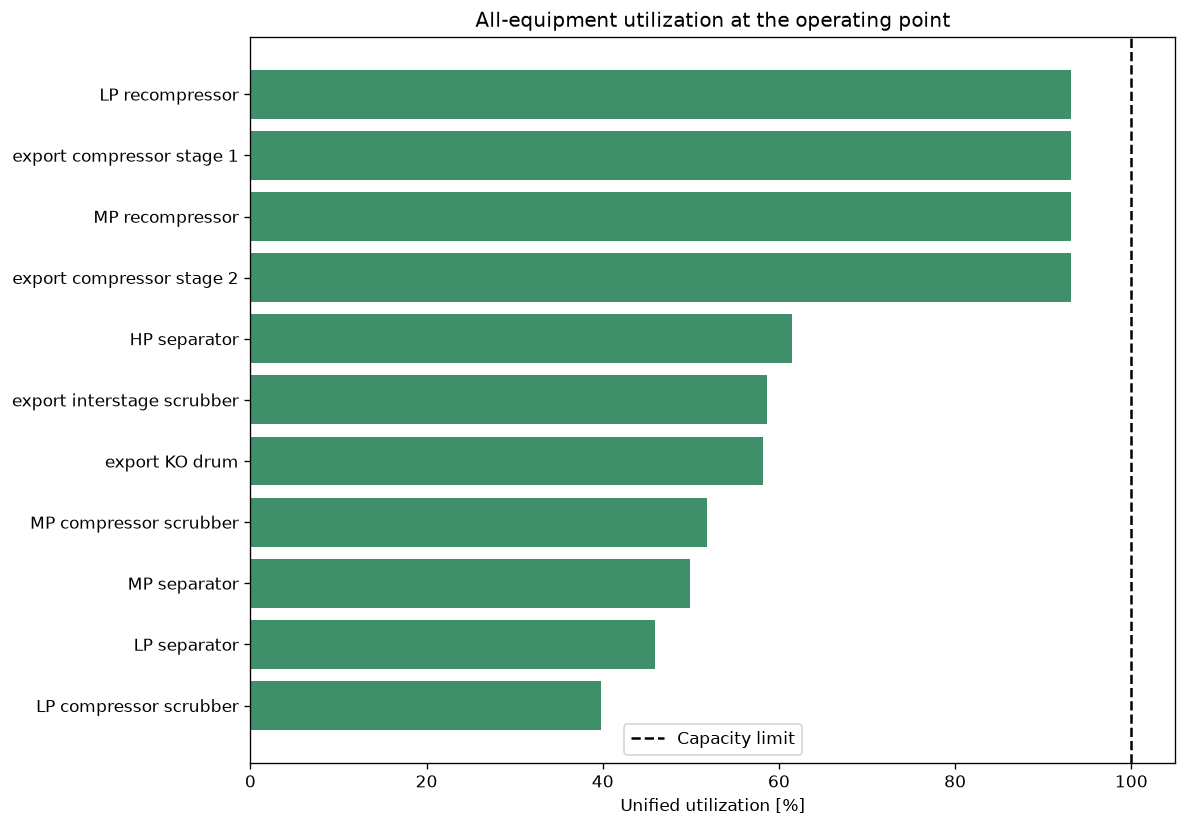

In [23]:
utilization_plot = operating_equipment.sort_values(
    "Utilization [%]"
)
colors = [
    "#3f8f6b" if value <= 100.0 else "firebrick"
    for value in utilization_plot["Utilization [%]"]
]
figure, axis = plt.subplots(figsize=(10.0, 7.0))
axis.barh(
    utilization_plot["Equipment"],
    utilization_plot["Utilization [%]"],
    color=colors,
)
axis.axvline(
    100.0,
    color="black",
    linestyle="--",
    label="Capacity limit",
)
axis.set(
    title="All-equipment utilization at the operating point",
    xlabel="Unified utilization [%]",
)
axis.legend()
figure.tight_layout()
plt.show()

## 14. Reservoir depletion

The process and gathering system are held fixed while reservoir pressure declines. Each
new IPR is intersected with the same calculated system curve. If the IPR cannot reach the
surface requirement, the well is no longer naturally deliverable in this screening model.

In [24]:
depletion_rows = []
for reservoir_pressure_bara in [
    250.0,
    230.0,
    210.0,
    190.0,
]:
    depletion_residual = (
        np.array(
            [
                ipr_pressure(
                    rate,
                    reservoir_pressure_bara,
                )
                for rate in system_curve_table[
                    "Rate [MSm³/day]"
                ]
            ]
        )
        - system_curve_table[
            "System BHP [bara]"
        ].to_numpy()
    )
    indices = np.where(
        depletion_residual[:-1]
        * depletion_residual[1:]
        <= 0.0
    )[0]
    if len(indices) == 0:
        rate = np.nan
        status = "No natural-flow crossing"
    else:
        index = int(indices[0])
        rates_pair = system_curve_table[
            "Rate [MSm³/day]"
        ].to_numpy()[index : index + 2]
        residual_pair = depletion_residual[
            index : index + 2
        ]
        rate = float(
            np.interp(
                0.0,
                residual_pair[::-1],
                rates_pair[::-1],
            )
        )
        rate = min(rate, topside_capacity_msm3_day)
        status = "Deliverable"
    depletion_rows.append(
        {
            "Reservoir pressure [bara]": (
                reservoir_pressure_bara
            ),
            "Operating rate [MSm³/day]": rate,
            "Status": status,
        }
    )

depletion_table = pd.DataFrame(depletion_rows)
display(depletion_table)

   Reservoir pressure [bara]  Operating rate [MSm³/day]       Status
0                      250.0                   2.703673  Deliverable
1                      230.0                   2.300405  Deliverable
2                      210.0                   1.895859  Deliverable
3                      190.0                   1.502500  Deliverable


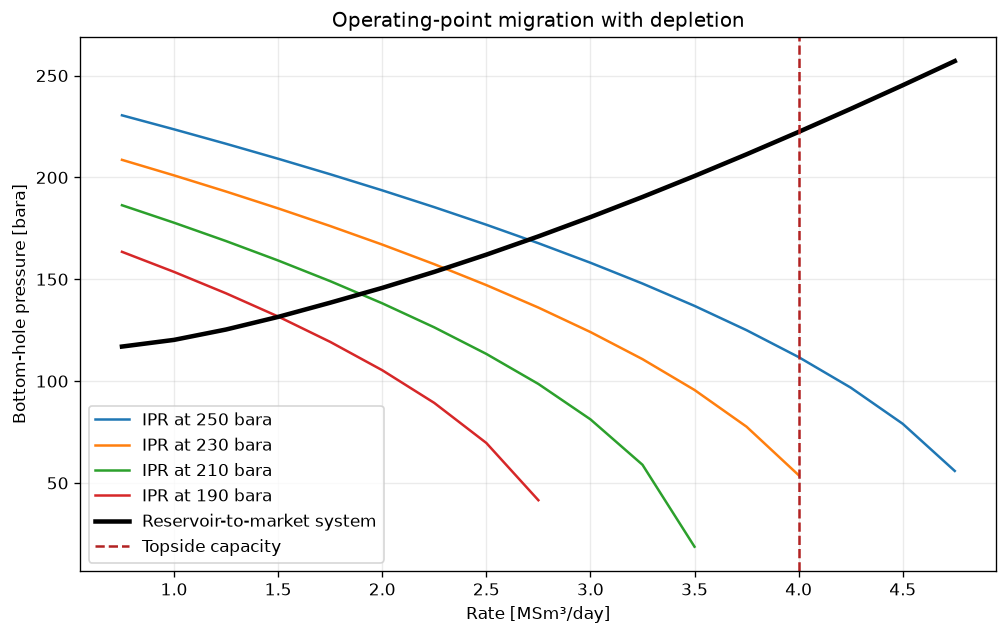

In [25]:
figure, axis = plt.subplots(figsize=(8.5, 5.4))
for reservoir_pressure_bara in [
    250.0,
    230.0,
    210.0,
    190.0,
]:
    axis.plot(
        system_curve_table["Rate [MSm³/day]"],
        [
            ipr_pressure(rate, reservoir_pressure_bara)
            for rate in system_curve_table[
                "Rate [MSm³/day]"
            ]
        ],
        label=f"IPR at {reservoir_pressure_bara:.0f} bara",
    )
axis.plot(
    system_curve_table["Rate [MSm³/day]"],
    system_curve_table["System BHP [bara]"],
    color="black",
    linewidth=2.7,
    label="Reservoir-to-market system",
)
axis.axvline(
    topside_capacity_msm3_day,
    color="firebrick",
    linestyle="--",
    label="Topside capacity",
)
axis.set(
    title="Operating-point migration with depletion",
    xlabel="Rate [MSm³/day]",
    ylabel="Bottom-hole pressure [bara]",
)
axis.grid(alpha=0.25)
axis.legend()
figure.tight_layout()
plt.show()

## 15. Capacity-aware ECLIPSE `VFPPROD`

A standard `VFPPROD` table maps

$$
p_{wf}
=
F\left(q,p_{TH},WC,GOR,ALQ\right).
$$

The axes are ordered as flow, THP, water cut, gas-oil ratio, and artificial-lift quantity.
This synthetic gas case uses one zero value for each inactive compositional/artificial-lift
axis. The flow axis stops at 95% of the calculated topside capacity.

The topside constraints are **not** hidden inside BHP values. A reservoir simulator should
combine this well table with surface-network and group constraints. The complementary
reservoir-to-market table written below carries the calculated process boundary,
utilization, feasibility, and bottleneck.

In [26]:
vfp_flow_msm3_day = np.linspace(
    0.25,
    0.95 * topside_capacity_msm3_day,
    11,
)
vfp_flow_sm3_day = vfp_flow_msm3_day * 1.0e6
vfp_thp_bara = np.array(
    [60.0, 70.0, 80.0, 90.0, 100.0]
)
vfp_bhp_bara = np.empty(
    (
        len(vfp_flow_sm3_day),
        len(vfp_thp_bara),
    )
)
for thp_index, thp_bara in enumerate(vfp_thp_bara):
    curve_well = make_well(
        tubing_head_pressure_bara=float(thp_bara)
    )
    curve = np.asarray(
        curve_well.generateVLPCurve(
            vfp_flow_sm3_day
        ),
        dtype=float,
    )
    vfp_bhp_bara[:, thp_index] = curve[1]

vfp_table = pd.DataFrame(
    vfp_bhp_bara,
    index=vfp_flow_msm3_day,
    columns=vfp_thp_bara,
)
vfp_table.index.name = "Gas rate [MSm³/day]"
vfp_table.columns.name = "True THP [bara]"
display(vfp_table.round(3))

vfp_reservoir_pressures_bara = np.array(
    [250.0, 230.0, 210.0, 190.0]
)
nodal_rate_matrix = np.full(
    (
        len(vfp_reservoir_pressures_bara),
        len(vfp_thp_bara),
    ),
    np.nan,
)
for pressure_index, reservoir_pressure_bara in enumerate(
    vfp_reservoir_pressures_bara
):
    ipr_values = np.array(
        [
            ipr_pressure(
                rate,
                reservoir_pressure_bara,
            )
            for rate in vfp_flow_msm3_day
        ]
    )
    for thp_index in range(len(vfp_thp_bara)):
        residual_values = (
            ipr_values - vfp_bhp_bara[:, thp_index]
        )
        crossing = np.where(
            residual_values[:-1]
            * residual_values[1:]
            <= 0.0
        )[0]
        if len(crossing) == 0:
            continue
        index = int(crossing[0])
        nodal_rate_matrix[
            pressure_index,
            thp_index,
        ] = float(
            np.interp(
                0.0,
                residual_values[
                    index : index + 2
                ][::-1],
                vfp_flow_msm3_day[
                    index : index + 2
                ][::-1],
            )
        )

nodal_rate_table = pd.DataFrame(
    nodal_rate_matrix,
    index=vfp_reservoir_pressures_bara,
    columns=vfp_thp_bara,
)
nodal_rate_table.index.name = "Reservoir pressure [bara]"
nodal_rate_table.columns.name = "True THP [bara]"
display(nodal_rate_table.round(3))

True THP [bara]        60.0     70.0     80.0     90.0     100.0
Gas rate [MSm³/day]                                             
0.250                103.033  114.346  125.633  136.895  148.130
0.605                105.223  116.477  127.711  138.923  150.112
0.960                108.681  119.843  130.993  142.127  153.244
1.315                113.264  124.304  135.341  146.372  157.393
1.670                118.884  129.775  140.674  151.578  162.482
2.025                125.480  136.196  146.934  157.689  168.455
2.380                133.006  143.523  154.076  164.661  175.270
2.735                141.426  151.718  162.066  172.460  182.894
3.090                150.708  160.754  170.874  181.059  191.298
3.445                160.826  170.603  180.476  190.432  200.460
3.800                171.758  181.245  190.851  200.560  210.359
True THP [bara]            60.0   70.0   80.0   90.0   100.0
Reservoir pressure [bara]                                   
250.0                      3.144 

In [27]:
bhp_table_5d = np.empty(
    (
        len(vfp_flow_sm3_day),
        len(vfp_thp_bara),
        1,
        1,
        1,
    )
)
bhp_table_5d[:, :, 0, 0, 0] = vfp_bhp_bara

java_double_5d = jpype.JArray(jpype.JDouble, 5)
exporter = EclipseVFPExporter(21)
exporter.setTableTitle(
    "Capacity-aware synthetic reservoir-to-market producer"
)
exporter.setDatumDepth(TUBING_LENGTH_M)
exporter.setFlowRateType("GAS")
exporter.setUnitSystem("METRIC")
exporter.setFlowRates(vfp_flow_sm3_day)
exporter.setTHPs(vfp_thp_bara)
exporter.setWaterCuts([0.0])
exporter.setGORs([0.0])
exporter.setALQs([0.0])
exporter.setBHPTable(
    java_double_5d(bhp_table_5d.tolist())
)

vfpprod_text = str(exporter.getVFPPRODString())
vfpprod_path = Path(
    "/tmp/PRODUCER_A_CAPACITY_AWARE_VFPPROD.inc"
)
vfpprod_path.write_text(
    vfpprod_text,
    encoding="utf-8",
)
market_curve_path = Path(
    "/tmp/PRODUCER_A_RESERVOIR_TO_MARKET.csv"
)
system_curve_table.to_csv(
    market_curve_path,
    index=False,
)

print(f"Wrote {vfpprod_path}")
print(f"Wrote {market_curve_path}")
print(f"VFPPROD characters: {len(vfpprod_text)}")
print(f"5D BHP shape: {bhp_table_5d.shape}")
print("\n".join(vfpprod_text.splitlines()[:18]))

Wrote /tmp/PRODUCER_A_CAPACITY_AWARE_VFPPROD.inc
Wrote /tmp/PRODUCER_A_RESERVOIR_TO_MARKET.csv
VFPPROD characters: 989
5D BHP shape: (11, 5, 1, 1, 1)
---------------------------------------------------------------------------
-- Capacity-aware synthetic reservoir-to-market producer
-- Generated by NeqSim EclipseVFPExporter
-- Units: METRIC
---------------------------------------------------------------------------
VFPPROD

  21  2800  'GAS'  'WCT'  'GOR'  /
  2.50E+05  6.05E+05  9.60E+05  1.32E+06  1.67E+06  2.03E+06  
  2.38E+06  2.74E+06  3.09E+06  3.45E+06  3.80E+06  
/
  60  70  80  90  100  
/
  0
/
  0
/
  0


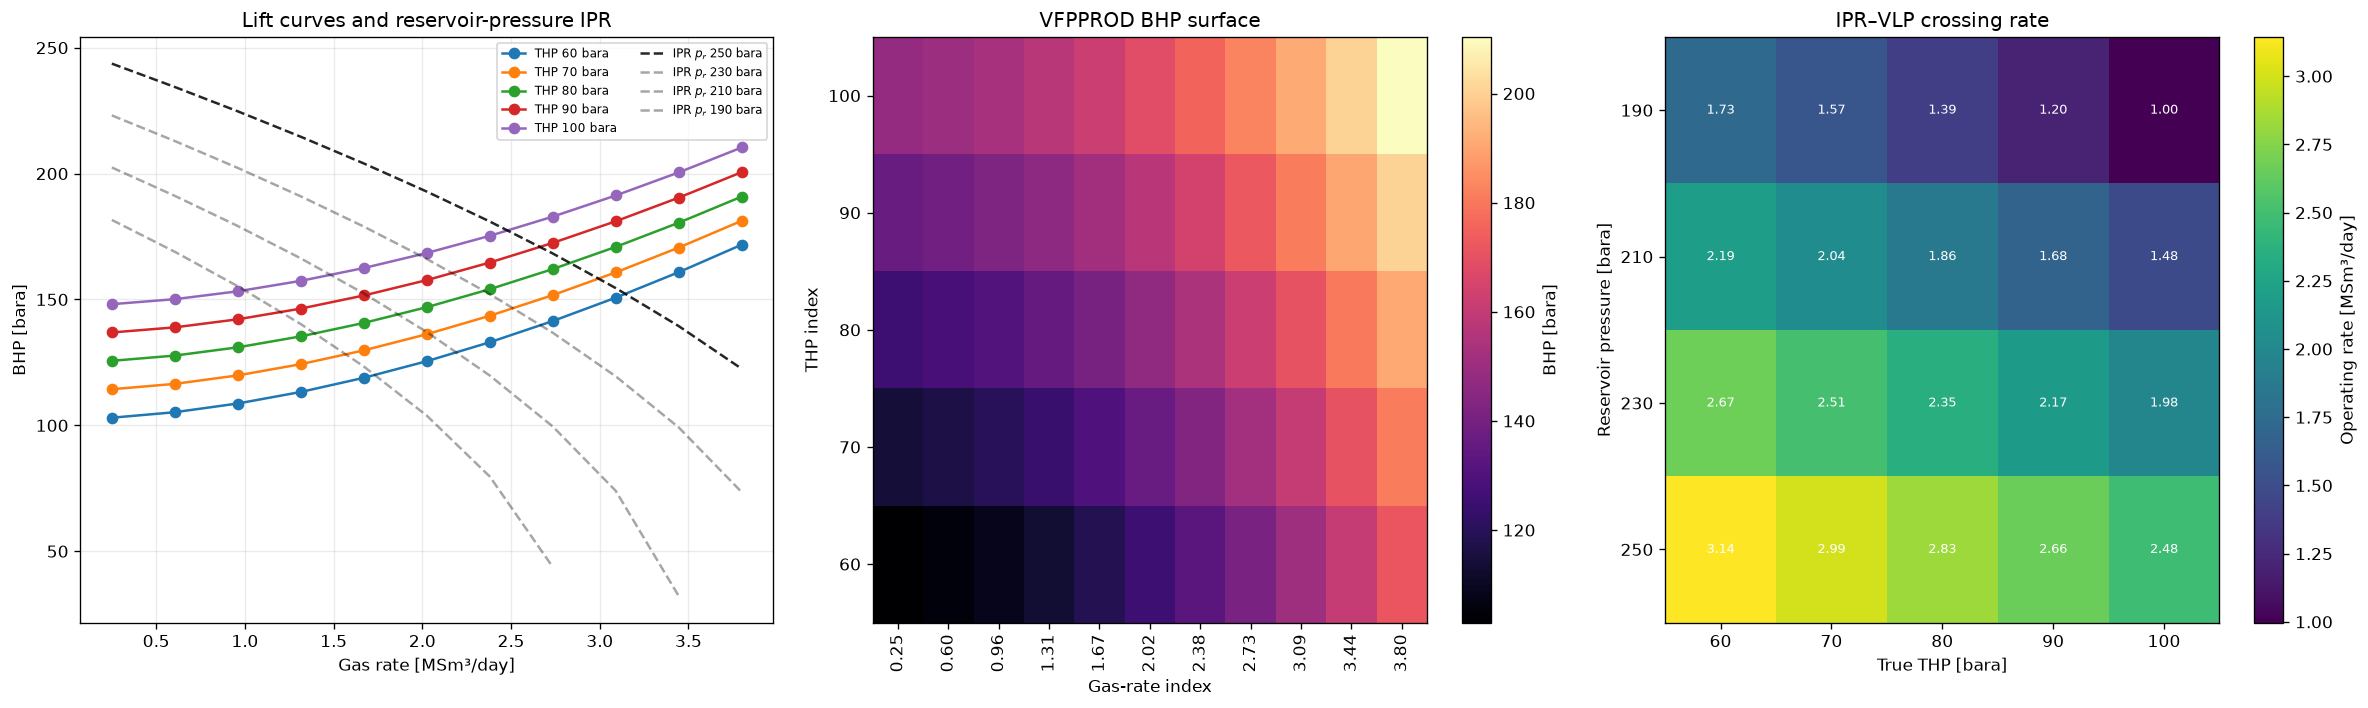

In [28]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(20.0, 6.0),
)
for thp_bara in vfp_thp_bara:
    axes[0].plot(
        vfp_flow_msm3_day,
        vfp_table[thp_bara],
        marker="o",
        label=f"THP {thp_bara:.0f} bara",
    )
for reservoir_pressure_bara in (
    vfp_reservoir_pressures_bara
):
    axes[0].plot(
        vfp_flow_msm3_day,
        [
            ipr_pressure(
                rate,
                reservoir_pressure_bara,
            )
            for rate in vfp_flow_msm3_day
        ],
        color="black",
        linestyle="--",
        alpha=(
            0.85
            if reservoir_pressure_bara
            == RESERVOIR_PRESSURE_BARA
            else 0.35
        ),
        label=(
            f"IPR $p_r$ "
            f"{reservoir_pressure_bara:.0f} bara"
        ),
    )
axes[0].set(
    title="Lift curves and reservoir-pressure IPR",
    xlabel="Gas rate [MSm³/day]",
    ylabel="BHP [bara]",
)
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=7, ncol=2)

bhp_image = axes[1].imshow(
    vfp_bhp_bara.T,
    aspect="auto",
    origin="lower",
    cmap="magma",
)
axes[1].set(
    title="VFPPROD BHP surface",
    xlabel="Gas-rate index",
    ylabel="THP index",
    xticks=np.arange(len(vfp_flow_msm3_day)),
    yticks=np.arange(len(vfp_thp_bara)),
    xticklabels=[
        f"{value:.2f}"
        for value in vfp_flow_msm3_day
    ],
    yticklabels=[
        f"{value:.0f}" for value in vfp_thp_bara
    ],
)
axes[1].tick_params(axis="x", rotation=90)
figure.colorbar(
    bhp_image,
    ax=axes[1],
    label="BHP [bara]",
)

rate_image = axes[2].imshow(
    nodal_rate_matrix,
    aspect="auto",
    origin="lower",
    cmap="viridis",
)
axes[2].set(
    title="IPR–VLP crossing rate",
    xlabel="True THP [bara]",
    ylabel="Reservoir pressure [bara]",
    xticks=np.arange(len(vfp_thp_bara)),
    yticks=np.arange(
        len(vfp_reservoir_pressures_bara)
    ),
    xticklabels=[
        f"{value:.0f}" for value in vfp_thp_bara
    ],
    yticklabels=[
        f"{value:.0f}"
        for value in vfp_reservoir_pressures_bara
    ],
)
for pressure_index in range(
    len(vfp_reservoir_pressures_bara)
):
    for thp_index in range(len(vfp_thp_bara)):
        value = nodal_rate_matrix[
            pressure_index,
            thp_index,
        ]
        if np.isfinite(value):
            axes[2].text(
                thp_index,
                pressure_index,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="white",
                fontsize=8,
            )
figure.colorbar(
    rate_image,
    ax=axes[2],
    label="Operating rate [MSm³/day]",
)
figure.tight_layout()
plt.show()

## 16. Debottlenecking study

Debottlenecking must be evaluated at system level. A larger separator or compressor does
not increase production when the active constraint is well or flowline pressure loss.
Four topside concepts are therefore screened first: the installed base, 10% larger vessel
diameter and length, a 15% compressor-map flow rerate with 25% larger drivers, and the
combined topside upgrade.

The resulting process capacities are then combined with three hydraulic alternatives:
a 0.35 m flowline, 5.5 inch tubing, and both changes together. Operating rates are
recalculated at 250 and 190 bara reservoir pressure. Capacity multipliers represent
screening concepts such as rerated wheels, parallel capacity, or replacement drivers;
vendor engineering is required before treating them as equipment modifications.

In [29]:
topside_upgrade_cases = {
    "Base topside": {
        "vessel_diameter_scale": 1.0,
        "vessel_length_scale": 1.0,
        "compressor_map_flow_scale": 1.0,
        "driver_rating_scale": 1.0,
    },
    "Larger vessels": {
        "vessel_diameter_scale": 1.10,
        "vessel_length_scale": 1.10,
        "compressor_map_flow_scale": 1.0,
        "driver_rating_scale": 1.0,
    },
    "Compressor rerate": {
        "vessel_diameter_scale": 1.0,
        "vessel_length_scale": 1.0,
        "compressor_map_flow_scale": 1.15,
        "driver_rating_scale": 1.25,
    },
    "Integrated topside": {
        "vessel_diameter_scale": 1.10,
        "vessel_length_scale": 1.10,
        "compressor_map_flow_scale": 1.15,
        "driver_rating_scale": 1.25,
    },
}
debottleneck_rate_grid = np.arange(
    3.50,
    6.01,
    0.25,
)

def screen_topside_upgrade(upgrade):
    rows = []
    for rate_msm3_day in debottleneck_rate_grid:
        rate_results = []
        for hp_pressure_bara in hp_pressure_candidates:
            try:
                result = evaluate_topside(
                    float(rate_msm3_day),
                    float(hp_pressure_bara),
                    **upgrade,
                )
            except Exception as error:
                result = {
                    "Rate [MSm³/day]": float(
                        rate_msm3_day
                    ),
                    "HP pressure [bara]": float(
                        hp_pressure_bara
                    ),
                    "Feasible": False,
                    "Maximum utilization": np.inf,
                    "Limiting equipment": (
                        f"Simulation failure: {error}"
                    ),
                }
            rate_results.append(result)
        feasible_results = [
            result
            for result in rate_results
            if result["Feasible"]
        ]
        if feasible_results:
            selected = min(
                feasible_results,
                key=lambda result: result[
                    "HP pressure [bara]"
                ],
            )
        else:
            selected = min(
                rate_results,
                key=lambda result: result[
                    "Maximum utilization"
                ],
            )
        rows.append(selected)

    feasible_rows = [
        row for row in rows if row["Feasible"]
    ]
    if not feasible_rows:
        raise RuntimeError(
            "Upgrade has no feasible screened rate."
        )
    capacity = max(
        row["Rate [MSm³/day]"]
        for row in feasible_rows
    )
    excluded_rows = [
        row
        for row in rows
        if row["Rate [MSm³/day]"] > capacity
    ]
    if excluded_rows:
        next_row = excluded_rows[0]
        bottleneck = next_row["Limiting equipment"]
    else:
        bottleneck = "Screen upper bound"
    return capacity, bottleneck, rows


topside_study_rows = []
topside_study_details = {}
for scenario, upgrade in topside_upgrade_cases.items():
    capacity, bottleneck, rows = screen_topside_upgrade(
        upgrade
    )
    topside_study_details[scenario] = rows
    topside_study_rows.append(
        {
            "Scenario": scenario,
            "Topside capacity [MSm³/day]": capacity,
            "Next limiting equipment": bottleneck,
        }
    )

topside_debottleneck_table = pd.DataFrame(
    topside_study_rows
)
capacity_by_scenario = dict(
    zip(
        topside_debottleneck_table["Scenario"],
        topside_debottleneck_table[
            "Topside capacity [MSm³/day]"
        ],
    )
)
display(topside_debottleneck_table.round(3))

             Scenario  Topside capacity [MSm³/day]    Next limiting equipment
0        Base topside                         4.00            LP recompressor
1      Larger vessels                         4.00            LP recompressor
2   Compressor rerate                         4.25               HP separator
3  Integrated topside                         4.75  export compressor stage 2


In [30]:
def calculate_hydraulic_system_curve(
    tubing_diameter_in,
    flowline_diameter_m,
):
    system_bhp_values = []
    for _, process_row in (
        optimal_process_table.iterrows()
    ):
        rate = float(
            process_row["Rate [MSm³/day]"]
        )
        arrival_pressure = float(
            process_row["HP pressure [bara]"]
        )
        wellhead_pressure = (
            required_wellhead_pressure(
                rate,
                arrival_pressure,
                flowline_diameter_m,
            )
        )
        well = make_well(
            tubing_head_pressure_bara=(
                wellhead_pressure
            ),
            tubing_diameter_in=(
                tubing_diameter_in
            ),
        )
        curve = np.asarray(
            well.generateVLPCurve(
                np.array([rate * 1.0e6])
            ),
            dtype=float,
        )
        system_bhp_values.append(
            float(curve[1, 0])
        )
    return np.array(system_bhp_values)


hydraulic_curves = {
    "Base hydraulics": system_curve_table[
        "System BHP [bara]"
    ].to_numpy(),
    "0.35 m flowline": (
        calculate_hydraulic_system_curve(
            TUBING_DIAMETER_IN,
            0.35,
        )
    ),
    "5.5 in tubing": (
        calculate_hydraulic_system_curve(
            5.5,
            FLOWLINE_DIAMETER_M,
        )
    ),
    "Tubing + flowline": (
        calculate_hydraulic_system_curve(
            5.5,
            0.35,
        )
    ),
}

def solve_capacity_bounded_rate(
    system_bhp_values,
    reservoir_pressure_bara,
    capacity_msm3_day,
):
    source_rates = system_curve_table[
        "Rate [MSm³/day]"
    ].to_numpy()
    capacity = min(
        capacity_msm3_day,
        float(source_rates.max()),
    )
    selected_rates = source_rates[
        source_rates < capacity
    ]
    selected_rates = np.append(
        selected_rates,
        capacity,
    )
    selected_system_bhp = np.interp(
        selected_rates,
        source_rates,
        system_bhp_values,
    )
    selected_ipr_bhp = np.array(
        [
            ipr_pressure(
                rate,
                reservoir_pressure_bara,
            )
            for rate in selected_rates
        ]
    )
    finite = np.isfinite(selected_ipr_bhp)
    selected_rates = selected_rates[finite]
    residual_values = (
        selected_ipr_bhp[finite]
        - selected_system_bhp[finite]
    )
    crossing = np.where(
        residual_values[:-1]
        * residual_values[1:]
        <= 0.0
    )[0]
    if len(crossing):
        index = int(crossing[0])
        rate = float(
            np.interp(
                0.0,
                residual_values[
                    index : index + 2
                ][::-1],
                selected_rates[
                    index : index + 2
                ][::-1],
            )
        )
        return rate, "Deliverability limited"
    if residual_values[-1] >= 0.0:
        return capacity, "Topside capacity limited"
    return np.nan, "No natural-flow crossing"


system_upgrade_cases = {
    "Base": {
        "curve": hydraulic_curves["Base hydraulics"],
        "capacity": capacity_by_scenario[
            "Base topside"
        ],
    },
    "Topside only": {
        "curve": hydraulic_curves["Base hydraulics"],
        "capacity": capacity_by_scenario[
            "Integrated topside"
        ],
    },
    "Flowline only": {
        "curve": hydraulic_curves[
            "0.35 m flowline"
        ],
        "capacity": capacity_by_scenario[
            "Base topside"
        ],
    },
    "Tubing only": {
        "curve": hydraulic_curves["5.5 in tubing"],
        "capacity": capacity_by_scenario[
            "Base topside"
        ],
    },
    "Tubing + flowline": {
        "curve": hydraulic_curves[
            "Tubing + flowline"
        ],
        "capacity": capacity_by_scenario[
            "Base topside"
        ],
    },
    "Integrated upgrade": {
        "curve": hydraulic_curves[
            "Tubing + flowline"
        ],
        "capacity": capacity_by_scenario[
            "Integrated topside"
        ],
    },
}

debottleneck_rows = []
for scenario, configuration in (
    system_upgrade_cases.items()
):
    for reservoir_pressure_bara in [250.0, 190.0]:
        rate, status = solve_capacity_bounded_rate(
            configuration["curve"],
            reservoir_pressure_bara,
            configuration["capacity"],
        )
        debottleneck_rows.append(
            {
                "Scenario": scenario,
                "Reservoir pressure [bara]": (
                    reservoir_pressure_bara
                ),
                "Operating rate [MSm³/day]": rate,
                "Status": status,
            }
        )

debottleneck_table = pd.DataFrame(
    debottleneck_rows
)
base_rates = (
    debottleneck_table[
        debottleneck_table["Scenario"] == "Base"
    ]
    .set_index("Reservoir pressure [bara]")[
        "Operating rate [MSm³/day]"
    ]
)
debottleneck_table["Rate gain [MSm³/day]"] = [
    row["Operating rate [MSm³/day]"]
    - base_rates.loc[
        row["Reservoir pressure [bara]"]
    ]
    for _, row in debottleneck_table.iterrows()
]
print(
    debottleneck_table.round(3).to_string(
        index=False
    )
)
best_initial_gain = float(
    debottleneck_table[
        debottleneck_table[
            "Reservoir pressure [bara]"
        ]
        == 250.0
    ]["Rate gain [MSm³/day]"].max()
)
print(
    "Best initial debottlenecking gain:",
    f"{best_initial_gain:.3f} MSm³/day",
)

          Scenario  Reservoir pressure [bara]  Operating rate [MSm³/day]                 Status  Rate gain [MSm³/day]
              Base                      250.0                      2.704 Deliverability limited                 0.000
              Base                      190.0                      1.503 Deliverability limited                 0.000
      Topside only                      250.0                      2.704 Deliverability limited                 0.000
      Topside only                      190.0                      1.503 Deliverability limited                 0.000
     Flowline only                      250.0                      2.859 Deliverability limited                 0.156
     Flowline only                      190.0                      1.566 Deliverability limited                 0.063
       Tubing only                      250.0                      3.055 Deliverability limited                 0.351
       Tubing only                      190.0           

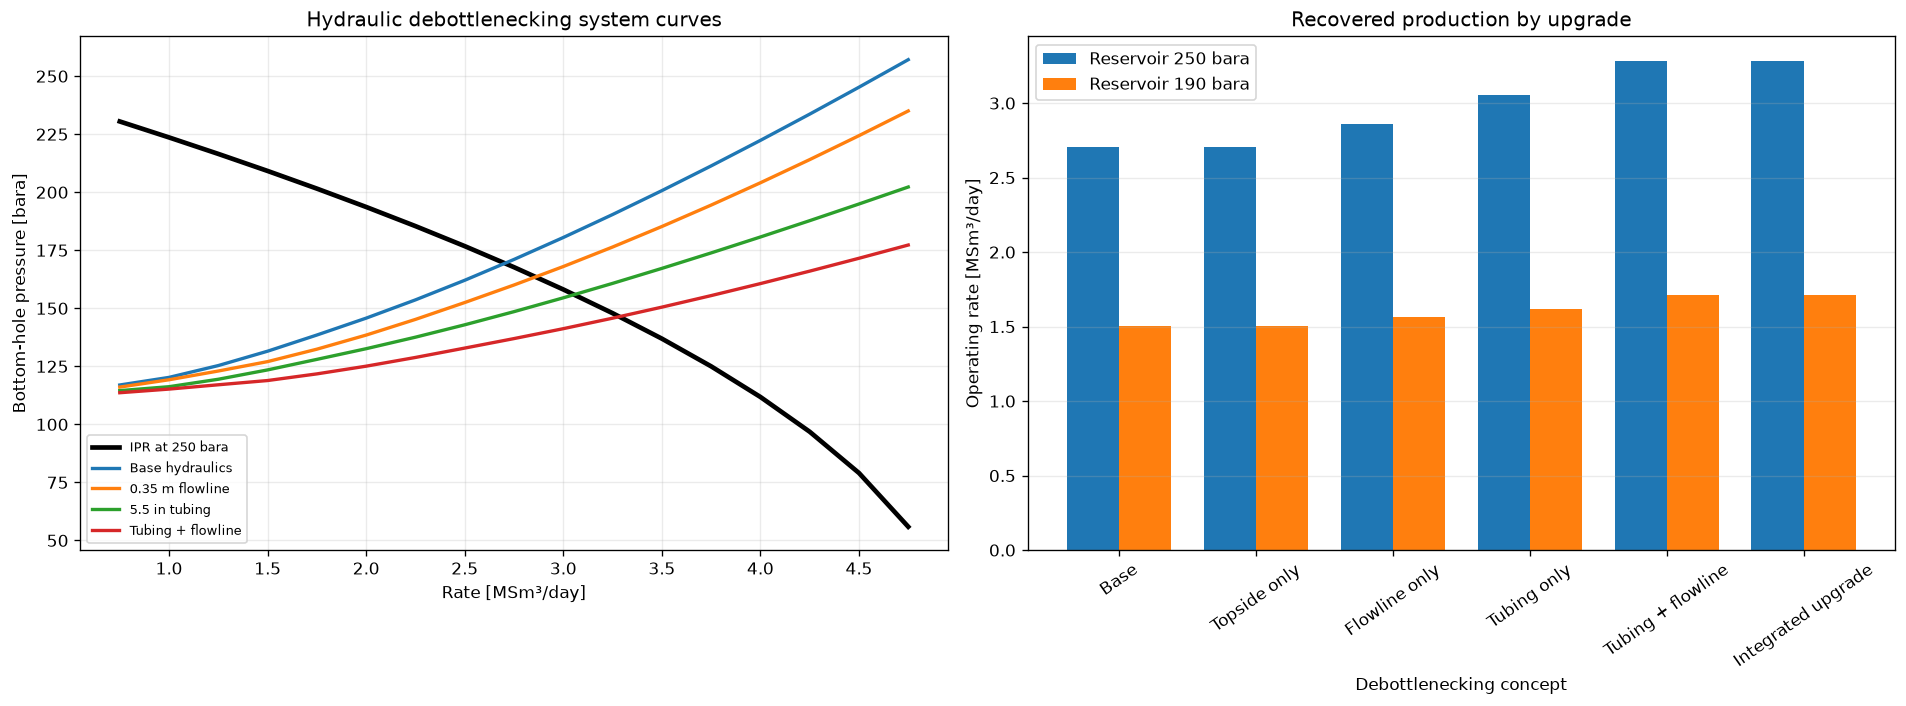

In [31]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(16.0, 6.0),
)
rate_axis = system_curve_table[
    "Rate [MSm³/day]"
]
axes[0].plot(
    rate_axis,
    [
        ipr_pressure(rate, 250.0)
        for rate in rate_axis
    ],
    color="black",
    linewidth=2.8,
    label="IPR at 250 bara",
)
for label, curve in hydraulic_curves.items():
    axes[0].plot(
        rate_axis,
        curve,
        linewidth=2.0,
        label=label,
    )
axes[0].set(
    title="Hydraulic debottlenecking system curves",
    xlabel="Rate [MSm³/day]",
    ylabel="Bottom-hole pressure [bara]",
)
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

rate_pivot = debottleneck_table.pivot(
    index="Scenario",
    columns="Reservoir pressure [bara]",
    values="Operating rate [MSm³/day]",
)
rate_pivot = rate_pivot.loc[
    list(system_upgrade_cases)
]
x_positions = np.arange(len(rate_pivot))
bar_width = 0.38
axes[1].bar(
    x_positions - bar_width / 2.0,
    rate_pivot[250.0],
    width=bar_width,
    label="Reservoir 250 bara",
)
axes[1].bar(
    x_positions + bar_width / 2.0,
    rate_pivot[190.0],
    width=bar_width,
    label="Reservoir 190 bara",
)
axes[1].set(
    title="Recovered production by upgrade",
    xlabel="Debottlenecking concept",
    ylabel="Operating rate [MSm³/day]",
    xticks=x_positions,
    xticklabels=rate_pivot.index,
)
axes[1].tick_params(axis="x", rotation=35)
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend()
figure.tight_layout()
plt.show()

### Debottlenecking interpretation

The base topside accepts 4.00 MSm³/day, well above the initial single-well operating rate
of 2.704 MSm³/day. Larger vessels alone therefore add no plant capacity: the LP
recompressor remains limiting. Rerating compressor flow by 15% and drivers by 25% raises
screened capacity to 4.25 MSm³/day and transfers the bottleneck to the HP separator.
Combining that rerate with 10% larger vessels raises capacity to 4.75 MSm³/day, where
export compressor stage 2 becomes limiting.

Topside expansion alone recovers no production because reservoir-to-market hydraulics are
active first. A 0.35 m flowline recovers about 0.156 MSm³/day at 250 bara, 5.5 inch tubing
recovers about 0.351 MSm³/day, and both together recover about 0.581 MSm³/day. At 190 bara,
the combined hydraulic gain is about 0.207 MSm³/day. The integrated topside upgrade gives
the same well rate as the combined hydraulic case, confirming that extra process capacity
is not yet required for this producer.

## 17. Engineering validation

The final gate checks conservation, dimensions, live capacities, compressor-map topology,
process optimization, reservoir-pressure nodal trends, debottlenecking results, the
operating-point root, and ECLIPSE table structure. These checks are deliberately physical
and structural rather than exact golden numbers.

In [32]:
checks = {}
checks["composition closes"] = (
    abs(sum(COMPOSITION.values()) - 1.0) < 1.0e-12
)
checks["design mass balance closes"] = (
    abs(design_mass_residual) < 1.0e-8
)
checks["market pressure reached"] = (
    abs(
        design_case["export_ko"]
        .getGasOutStream()
        .getPressure("bara")
        - MARKET_PRESSURE_BARA
    )
    < 0.05
)
checks["all required vessel diameters positive"] = (
    required_design[
        "Required diameter [m]"
    ].gt(0.0).all()
)
checks["all installed vessel diameters positive"] = (
    vessel_design_table[
        "Installed diameter [m]"
    ].gt(0.0).all()
)
checks["all vessel lengths exceed three diameters"] = (
    (
        vessel_design_table["Installed length [m]"]
        >= 3.0
        * vessel_design_table[
            "Installed diameter [m]"
        ]
    ).all()
)
checks["design vessel utilization below target"] = (
    vessel_design_table[
        "Maximum utilization [%]"
    ].le(80.1).all()
)
checks["four compressor maps generated"] = (
    len(compressor_charts) == 4
)
checks["seven speed lines per compressor"] = (
    compressor_map_table.groupby("Compressor")[
        "Speed [rpm]"
    ].nunique().eq(7).all()
)
checks["five points per speed line"] = (
    compressor_map_table.groupby(
        ["Compressor", "Speed [rpm]"]
    )["Point"].count().eq(5).all()
)
surge_table = compressor_map_table[
    compressor_map_table["Position"] == "surge"
].sort_values(["Compressor", "Speed [rpm]"])
stonewall_table = compressor_map_table[
    compressor_map_table["Position"] == "stonewall"
].sort_values(["Compressor", "Speed [rpm]"])
checks["surge is left of stonewall"] = (
    surge_table["Flow [m³/h]"].to_numpy()
    < stonewall_table["Flow [m³/h]"].to_numpy()
).all()
checks["positive driver ratings"] = (
    driver_table["Installed driver [kW]"].gt(0.0).all()
)
checks["process grid contains feasible cases"] = (
    scenario_table["Feasible"].any()
)
checks["topside capacity lies on screened grid"] = (
    topside_capacity_msm3_day
    in process_rate_grid
)
checks["selected pressure is from candidate set"] = (
    optimal_process_table["HP pressure [bara]"]
    .isin(hp_pressure_candidates)
    .all()
)
checks["system flowline losses are positive"] = (
    system_curve_table["Flowline loss [bar]"]
    .gt(0.0)
    .all()
)
checks["one feasible operating crossing"] = (
    len(crossing_indices) == 1
)
checks["operating-point residual closes"] = (
    abs(crossing_residual_bar) < 1.0e-10
)
checks["operating rate respects capacity"] = (
    operating_rate_msm3_day
    <= topside_capacity_msm3_day
)
checks["operating pressures are ordered"] = (
    operating_bhp_bara
    > operating_whp_bara
    > operating_hp_pressure
)
checks["depletion does not raise deliverability"] = (
    depletion_table[
        "Operating rate [MSm³/day]"
    ].dropna().is_monotonic_decreasing
)
checks["reservoir-pressure nodal matrix is finite"] = (
    np.isfinite(nodal_rate_matrix).all()
)
checks["higher THP lowers nodal rate"] = (
    np.diff(nodal_rate_matrix, axis=1) < 0.0
).all()
checks["depletion lowers nodal rate"] = (
    np.diff(nodal_rate_matrix, axis=0) < 0.0
).all()
checks["topside upgrades do not reduce capacity"] = (
    topside_debottleneck_table[
        "Topside capacity [MSm³/day]"
    ].ge(
        capacity_by_scenario["Base topside"]
    ).all()
)
checks["debottlenecking does not reduce production"] = (
    debottleneck_table[
        "Rate gain [MSm³/day]"
    ].ge(-1.0e-10).all()
)
checks["topside-only upgrade has no current gain"] = (
    debottleneck_table[
        (
            debottleneck_table["Scenario"]
            == "Topside only"
        )
        & (
            debottleneck_table[
                "Reservoir pressure [bara]"
            ]
            == 250.0
        )
    ]["Rate gain [MSm³/day]"]
    .abs()
    .lt(1.0e-8)
    .all()
)
checks["integrated upgrade recovers production"] = (
    debottleneck_table[
        debottleneck_table["Scenario"]
        == "Integrated upgrade"
    ]["Rate gain [MSm³/day]"].gt(0.0).all()
)
checks["VFP flow axis respects process capacity"] = (
    vfp_flow_msm3_day.max()
    < topside_capacity_msm3_day
)
checks["VFP BHP rises with flow"] = (
    np.diff(vfp_bhp_bara, axis=0) > 0.0
).all()
checks["VFP BHP rises with THP"] = (
    np.diff(vfp_bhp_bara, axis=1) > 0.0
).all()
checks["VFP table axis order is five-dimensional"] = (
    bhp_table_5d.shape
    == (
        len(vfp_flow_sm3_day),
        len(vfp_thp_bara),
        1,
        1,
        1,
    )
)
checks["VFPPROD keyword present"] = (
    "VFPPROD" in vfpprod_text
)
checks["VFPPROD gas type present"] = (
    "GAS" in vfpprod_text
)
checks["VFPPROD file identity"] = (
    vfpprod_path.read_text(encoding="utf-8")
    == vfpprod_text
)
checks["market-system CSV written"] = (
    market_curve_path.is_file()
)
checks["all system results finite"] = (
    np.isfinite(
        system_curve_table[
            [
                "IPR BHP [bara]",
                "System BHP [bara]",
                "Required WHP [bara]",
                "Flowline loss [bar]",
            ]
        ].to_numpy()
    ).all()
)

validation_table = pd.DataFrame(
    {
        "Check": list(checks),
        "Passed": list(checks.values()),
    }
)
display(validation_table)
if not all(checks.values()):
    failed = [
        name
        for name, passed in checks.items()
        if not passed
    ]
    raise AssertionError(
        "Engineering checks failed: "
        + ", ".join(failed)
    )

print(f"Passed {len(checks)} engineering checks.")

                                         Check  Passed
0                           composition closes    True
1                   design mass balance closes    True
2                      market pressure reached    True
3       all required vessel diameters positive    True
4      all installed vessel diameters positive    True
5    all vessel lengths exceed three diameters    True
6       design vessel utilization below target    True
7               four compressor maps generated    True
8             seven speed lines per compressor    True
9                   five points per speed line    True
10                  surge is left of stonewall    True
11                     positive driver ratings    True
12        process grid contains feasible cases    True
13      topside capacity lies on screened grid    True
14     selected pressure is from candidate set    True
15         system flowline losses are positive    True
16             one feasible operating crossing    True
17        

## 18. Interpretation and limitations

The workflow separates four decisions that are often conflated:

- **Nodal analysis:** where reservoir IPR crosses the full lift requirement.
- **Process capacity:** whether that crossing is feasible for every vessel, compressor map,
  recycle allowance, driver, and export boundary.
- **Debottlenecking:** whether an equipment upgrade actually lowers the active
  reservoir-to-market constraint and recovers production.
- **Reservoir-simulator export:** how a true THP-based `VFPPROD` table is bounded by the
  surface system without putting market pressure on the THP axis.

Separator dimensions are screening results from current NeqSim defaults, not certified
vessel designs. Compressor maps are synthetic maps generated around the design point, not
vendor guarantees. The pipeline uses a steady Beggs-Brill calculation and the well uses the
simplified VLP mode. Slugging, terrain liquid accumulation, hydrate risk, erosion,
transient anti-surge control, parallel trains, N+1 availability, production chemistry,
export quality, and economics remain outside this notebook.

For a project model, replace the synthetic fluid and maps, calibrate well and flowline
hydraulics, load approved mechanical-design standards, add dynamic controls and
availability, and connect the exported `VFPPROD` plus surface-system table to the
reservoir-network model.

## References

- [Field Development and Operations with NeqSim](https://equinor.github.io/neqsimhome/doc/field_development_and_operations/book_standalone.html)
- [NeqSim well simulation guide](https://equinor.github.io/neqsim/simulation/well_simulation_guide)
- [NeqSim separator mechanical design](https://equinor.github.io/neqsim/process/mechanicaldesign/separator)
- [NeqSim compressor charts](https://equinor.github.io/neqsim/process/equipment/compressor)
- [NeqSim flow-rate optimization](https://equinor.github.io/neqsim/process/optimization/flow-rate-optimization)
- [ECLIPSE-style VFP exporter source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/util/optimizer/EclipseVFPExporter.java)